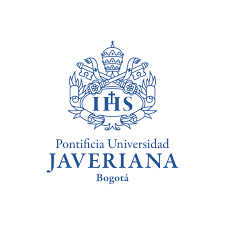
***Pontificia Universidad Javeriana***

# **Procesamiento de Alto Volumen de Datos**

### Taller: **Métricas y Machine Learning en PySpark**

---

| Campo | Detalle |
|---|---|
| **Autor** | Santiago Beltrán López |
| **Materia** | Procesamiento de Alto Volumen de Datos |
| **Fecha de Inicio** | 6 de mayo del 2026 |
| **Última actualización** | 13 de mayo del 2026 |
| **Entorno** | Apache Spark — Cluster HDFS |

---


## 📋 Objetivos del Taller

El presente taller tiene como propósito aplicar de forma práctica los conceptos de procesamiento distribuido de datos mediante **Apache PySpark**, enfocándose en el ciclo completo de un proyecto de Machine Learning:

1. **Carga y diagnóstico de datos** desde el ecosistema HDFS hacia un DataFrame distribuido de PySpark.
2. **Exploración y análisis descriptivo** de variables numéricas y categóricas del dataset bancario `bank-full.csv`.
3. **Preparación y limpieza de datos**: tratamiento de valores atípicos, desbalance de clases y variables no informativas.
4. **Codificación y vectorización** de variables mediante pipelines de Spark ML (StringIndexer, OneHotEncoder, VectorAssembler).
5. **Entrenamiento y evaluación** de cinco modelos de clasificación binaria: Regresión Logística, Árbol de Decisión, Random Forest, Gradient Boosted Tree y SVM.
6. **Comparación cuantitativa** de modelos mediante un amplio conjunto de métricas de rendimiento.

> **Contexto del dataset**: El conjunto de datos `bank-full.csv` proviene de una campaña de marketing telefónico de una entidad bancaria portuguesa. El objetivo de predicción (`y`) indica si el cliente suscribió o no un depósito a plazo fijo.


---
# 1. Configuración del Entorno


## 1.1 Instalación de Dependencias

Se instalan todas las librerías necesarias para el análisis: `seaborn` y `matplotlib` para visualización, `pandas` y `numpy` para manipulación de datos en memoria, `scikit-learn` para el cálculo de la curva ROC, `findspark` para localizar la instalación de Spark en el entorno, y `tensorflow` como dependencia de soporte.


In [1]:
# Instalación de librerías requeridas para el taller
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install findspark
!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## 1.2 Importación de Librerías

Se importan los módulos del ecosistema Python y PySpark. Se destacan los módulos de `pyspark.ml` que proveen las herramientas de Machine Learning distribuido, y `sklearn.metrics` para la construcción de la curva ROC a nivel de driver.


In [2]:
# Librerías estándar de análisis y visualización
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Inicialización de findspark para localizar Spark en el sistema
import findspark
findspark.init()

# Módulos de PySpark: SQL, contexto distribuido y ML
from pyspark.sql import functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import SQLContext
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# sklearn solo para cálculo de curva ROC (operación en driver, no distribuida)
from sklearn.metrics import roc_curve, auc


## 1.3 Inicialización de la Sesión Spark

Se configura y crea la sesión de Spark apuntando al clúster maestro en `spark://10.43.101.26:7077`. El modo de scheduling **FAIR** permite distribuir los recursos del clúster de forma equitativa entre múltiples aplicaciones concurrentes, evitando que un único job monopolice el clúster.


In [4]:
# Configuración del clúster Spark
configura = SparkConf()
# Modo de planificación FAIR: distribución equitativa de recursos entre jobs
configura.set("spark.schudeler.mode", "FAIR")
configura.set("spark.schudeler.allocation", "Almacen/Spark/conf/fairschudeler.xml")
# Dirección del nodo maestro del clúster
configura.setMaster("spark://10.43.101.26:7077")
configura.setAppName("Metricas_Banca.Beltran")

# Creación de la sesión Spark (punto de entrada a la API de alto nivel)
sparkBeltran = SparkSession.builder.config(conf=configura).getOrCreate()
sparkBeltran


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 18:47:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
# Verificación del nodo maestro al que se conectó la sesión
sparkBeltran.sparkContext.master


'spark://10.43.101.26:7077'

---
# 2. Almacenamiento y Carga de Datos


## 2.1 Carga Inicial del Dataset en PySpark

Se carga el archivo `bank-full.csv` directamente desde el sistema de archivos local hacia un **DataFrame distribuido de PySpark**. El separador utilizado es punto y coma (`;`), formato estándar de este dataset. La opción `header=true` permite que Spark infiera los nombres de las columnas desde la primera fila del archivo.

Es importante notar que PySpark, al leer el CSV, infiere todos los tipos de datos como `string` por defecto, por lo que será necesario realizar un casting explícito de las variables numéricas en el paso siguiente.


In [6]:
# Lectura del dataset en formato CSV con separador ';'
# header=true: primera fila como nombres de columna
df00 = sparkBeltran.read.format("csv") \
    .option("sep", ";") \
    .option("header", "true") \
    .load("file:///Almacen/bank-full.csv")

# Vista previa de los primeros 12 registros
df00.show(12)


+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

## Descripción del Dataset — Bank Marketing

El dataset utilizado en este taller proviene del [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing) y corresponde a campañas de marketing telefónico realizadas por una institución bancaria portuguesa. El objetivo es predecir si un cliente suscribirá un depósito a plazo fijo (`y`).

El dataset contiene **17 variables** distribuidas en las siguientes categorías:

### Variables del Cliente (perfil demográfico y financiero)

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Entero | Edad del cliente |
| `job` | Categórica | Ocupación: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown` |
| `marital` | Categórica | Estado civil: `divorced` (incluye viudos), `married`, `single`, `unknown` |
| `education` | Categórica | Nivel educativo: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown` |
| `default` | Binaria | ¿Tiene crédito en incumplimiento? |
| `balance` | Entero | Saldo promedio anual en cuenta (euros) |
| `housing` | Binaria | ¿Tiene préstamo hipotecario activo? |
| `loan` | Binaria | ¿Tiene préstamo personal activo? |

### Variables de la Campaña Actual

| Variable | Tipo | Descripción |
|---|---|---|
| `contact` | Categórica | Canal de comunicación: `cellular`, `telephone` |
| `day_of_week` | Fecha | Día de la semana del último contacto |
| `month` | Fecha | Mes del último contacto: `jan` a `dec` |
| `duration` | Entero | Duración del último contacto en segundos. ⚠️ **Nota importante**: esta variable influye fuertemente en el resultado — si `duration=0` entonces `y='no'`. Sin embargo, su valor solo se conoce *después* de realizar la llamada, por lo que **no debe usarse en modelos de predicción en tiempo real**; se incluye únicamente con fines de benchmark. |
| `campaign` | Entero | Número de contactos realizados durante esta campaña para este cliente |

### Variables de Campañas Anteriores

| Variable | Tipo | Descripción |
|---|---|---|
| `pdays` | Entero | Días transcurridos desde el último contacto en una campaña anterior (`-1` indica que el cliente no fue contactado previamente) |
| `previous` | Entero | Número de contactos realizados antes de esta campaña |
| `poutcome` | Categórica | Resultado de la campaña de marketing anterior: `failure`, `nonexistent`, `success` |

### Variable Objetivo

| Variable | Tipo | Descripción |
|---|---|---|
| `y` | Binaria | ¿El cliente suscribió un depósito a plazo fijo? (`yes` / `no`) |

---
# 3. Diagnóstico y Exploración de Datos (EDA)


## 3.1 Descripción Estructural del Dataset

Se inspeccionan los nombres de las columnas y el esquema del DataFrame para comprender la estructura del dataset. El dataset `bank-full` contiene **17 variables** que describen características demográficas del cliente, información de la campaña de marketing actual y resultados de campañas anteriores.


In [7]:
# Listado de todas las columnas del dataset
df00.columns


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [8]:
# Esquema inferido por Spark: todos los campos aparecen como string (tipo por defecto en CSV)
df00.printSchema()


root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



> **Análisis**: Como es esperado en la lectura de archivos CSV con PySpark, todas las columnas son inferidas como tipo `string`. Las variables que conceptualmente son numéricas — como `age`, `balance`, `duration`, entre otras — deben ser convertidas explícitamente a su tipo correcto antes de cualquier operación analítica o de modelado.


## 3.2 Conversión de Tipos de Datos (Casting)

Se realiza el **casting explícito** de las siete variables numéricas del dataset hacia el tipo entero (`int`). Esta transformación es fundamental para:
- Habilitar operaciones aritméticas y estadísticas sobre dichas columnas.
- Permitir que PySpark optimice el plan de ejecución mediante Catalyst.
- Garantizar la correcta interpretación de los datos en las etapas de vectorización y modelado.

Cada `withColumn` genera un nuevo DataFrame inmutable — principio fundamental en la arquitectura de Spark — reemplazando la versión de tipo string de cada columna por su equivalente numérico.


In [9]:
# Definición de columnas del dataset y subconjunto de variables numéricas
nombreCol = ['age','job','marital','education','defult','balance','housing','loan',
             'contact','day','month','duration','campaign','pdays','previous','poutcome','y']
colINT = ['age','balance', 'day', 'duration','campaign','pdays','previous']

# Casting secuencial: cada columna numérica se convierte de string a integer
df01 = df00.withColumn("age",      df00.age.cast("int"))
df01 = df01.withColumn("balance",  df00.balance.cast("int"))
df01 = df01.withColumn("day",      df00.day.cast("int"))
df01 = df01.withColumn("duration", df00.duration.cast("int"))
df01 = df01.withColumn("campaign", df00.campaign.cast("int"))
df01 = df01.withColumn("pdays",    df00.pdays.cast("int"))
df01 = df01.withColumn("previous", df00.previous.cast("int"))

# Verificación de los tipos resultantes
df01.dtypes


[('age', 'int'),
 ('job', 'string'),
 ('marital', 'string'),
 ('education', 'string'),
 ('default', 'string'),
 ('balance', 'int'),
 ('housing', 'string'),
 ('loan', 'string'),
 ('contact', 'string'),
 ('day', 'int'),
 ('month', 'string'),
 ('duration', 'int'),
 ('campaign', 'int'),
 ('pdays', 'int'),
 ('previous', 'int'),
 ('poutcome', 'string'),
 ('y', 'string')]

In [10]:
# Vista previa del DataFrame con tipos ya corregidos
df01.show(12)


+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job| marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+--------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management| married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician|  single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur| married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar| married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown|  single|  unknown|     no|      1|     no|  no|unknown|  5|  may

In [11]:
# Verificación final del esquema con tipos de datos corregidos
df01.printSchema()


root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



## 3.3 Análisis de la Variable Dependiente `y` — Desbalance de Clases

La variable objetivo `y` es de naturaleza **binaria**: indica si el cliente suscribió (`yes`) o no (`no`) un depósito a plazo fijo. Antes de construir cualquier modelo, es crucial entender la distribución de esta variable, ya que el **desbalance de clases** es uno de los problemas más comunes en datos bancarios y de marketing.

Un desbalance pronunciado puede sesgar los modelos hacia la clase mayoritaria, resultando en métricas de *accuracy* engañosamente altas, pero con una capacidad nula para detectar la clase minoritaria (los clientes que sí suscriben).


In [12]:
# Conteo total de registros y distribución por clase de la variable objetivo
cantRegistros = df00.count()
cantY = df00.groupby("y").count()

# Se agrega el porcentaje relativo de cada clase para evaluar el desbalance
dfAUX = cantY.withColumn("Porcentaje", cantY["count"] * 100 / cantRegistros)
dfAUX.show()
dfAUX.toPandas()


+---+-----+------------------+
|  y|count|        Porcentaje|
+---+-----+------------------+
| no|39922| 88.30151954170445|
|yes| 5289|11.698480458295547|
+---+-----+------------------+



,y,count,Porcentaje
0,no,39922,88.30152
1,yes,5289,11.69848


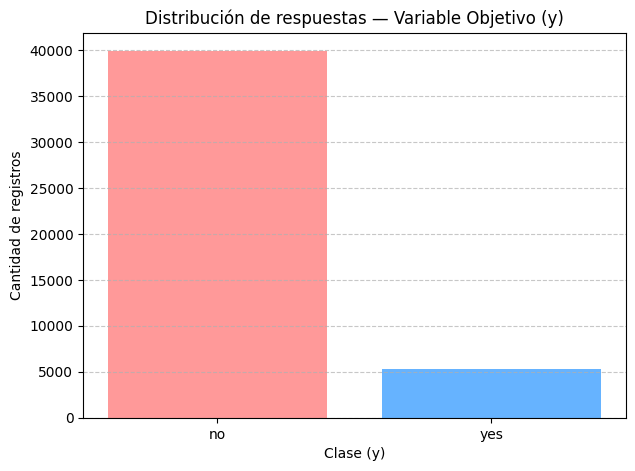

In [13]:
# Visualización del desbalance de clases mediante gráfico de barras
pdf = cantY.toPandas()

plt.figure(figsize=(7, 5))
plt.bar(pdf["y"], pdf["count"], color=['#ff9999', '#66b3ff'])
plt.title("Distribución de respuestas — Variable Objetivo (y)")
plt.xlabel("Clase (y)")
plt.ylabel("Cantidad de registros")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


> **Análisis**: El gráfico evidencia un **desbalance significativo** en la variable objetivo: aproximadamente el 88% de los registros corresponden a la clase `no` (no suscribió), mientras que solo el 12% pertenece a la clase `yes`. Este desequilibrio hace que los modelos entrenados sin corrección tiendan a predecir `no` de forma casi sistemática. Como solución, en la sección de preparación de datos se aplicará una técnica de **oversampling** sobre la clase minoritaria.


## 3.4 Estadísticas Descriptivas — Variables Numéricas

Se calculan las estadísticas descriptivas básicas (conteo, media, desviación estándar, mínimo y máximo) para todas las variables del dataset. Estas métricas permiten identificar rangos de valores, posibles anomalías y la dispersión de cada variable numérica.


In [14]:
# Estadísticas descriptivas generales del DataFrame (equivalente a .describe() de pandas)
df01.describe().toPandas()


26/05/25 18:47:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


## 3.5 Distribución de Variables Numéricas — Histogramas

Los histogramas permiten visualizar la **distribución de frecuencias** de cada variable numérica. Esto facilita la identificación de asimetrías, distribuciones multimodales y valores extremos. En el contexto bancario, variables como `balance` (saldo en cuenta) y `duration` (duración de la última llamada) suelen presentar colas largas hacia la derecha, lo que puede indicar la presencia de outliers que deben ser considerados en el preprocesamiento.


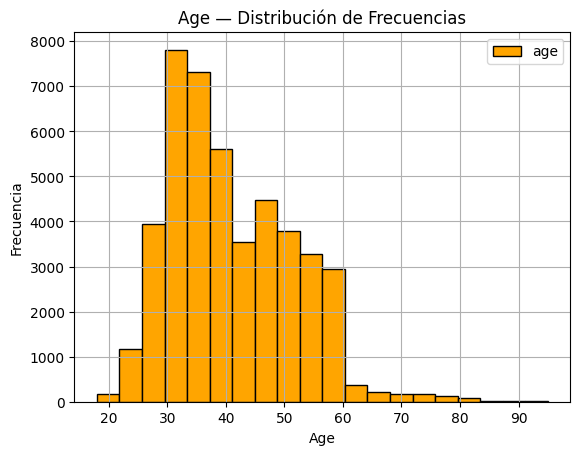

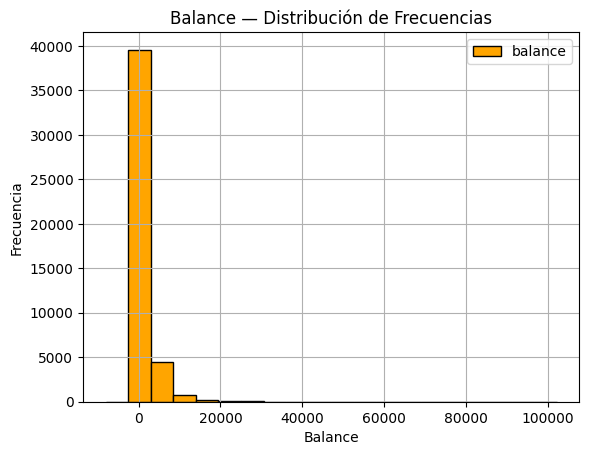

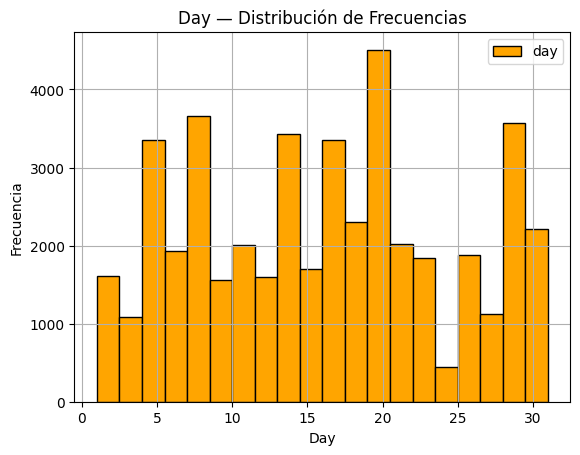

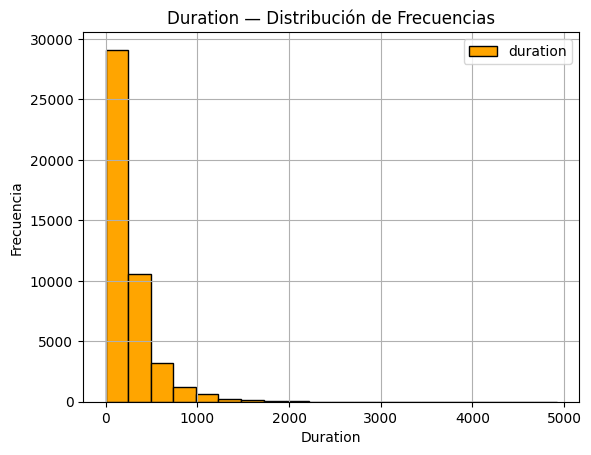

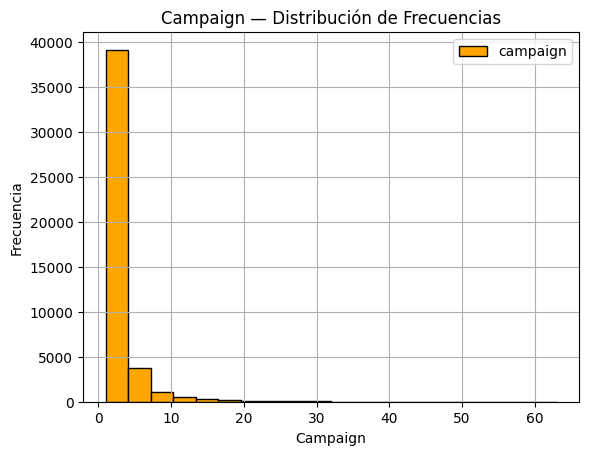

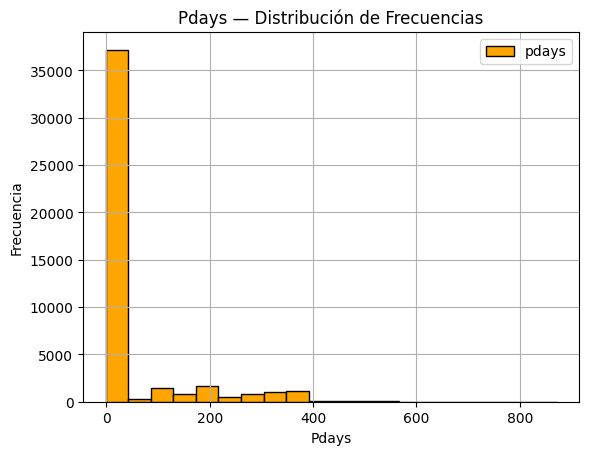

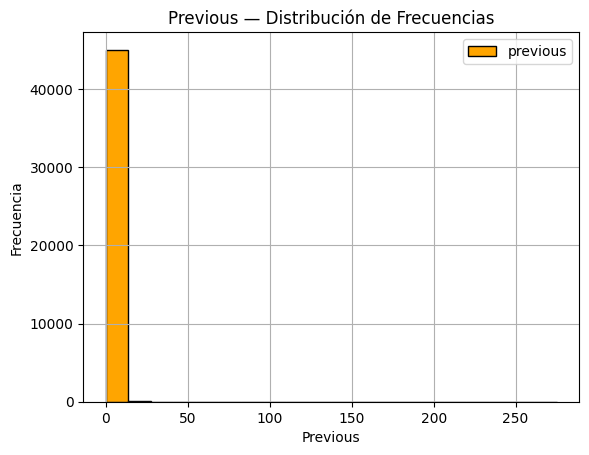

In [15]:
# Generación de histogramas para cada variable numérica del dataset
for col in colINT:
    # Se convierte la columna a pandas para graficar (operación collect en driver)
    histGra = df01.select(col).toPandas()
    histGra.plot(kind='hist', bins=20, edgecolor='black', color='orange')
    plt.ylabel('Frecuencia')
    plt.xlabel(col.capitalize())
    plt.title(f"{col.capitalize()} — Distribución de Frecuencias")
    plt.grid()
    plt.show()


> **Análisis**: Las variables `balance`, `duration` y `campaign` presentan distribuciones fuertemente sesgadas hacia la derecha (asimetría positiva), lo que sugiere la existencia de valores atípicos. En particular, `pdays` muestra una distribución bimodal con una concentración masiva en `-1`, valor que indica que el cliente **nunca fue contactado** en campañas anteriores — esto se tratará en la sección de preparación de datos.


## 3.6 Análisis Comparativo por Clase — Boxplots

Los diagramas de caja (*boxplots*) estratificados por la variable objetivo `y` permiten comparar la distribución de cada variable numérica entre los clientes que suscribieron (`yes`) y los que no lo hicieron (`no`). Esta visualización es clave para identificar qué variables tienen mayor poder discriminante entre las dos clases y podrían ser relevantes para los modelos.


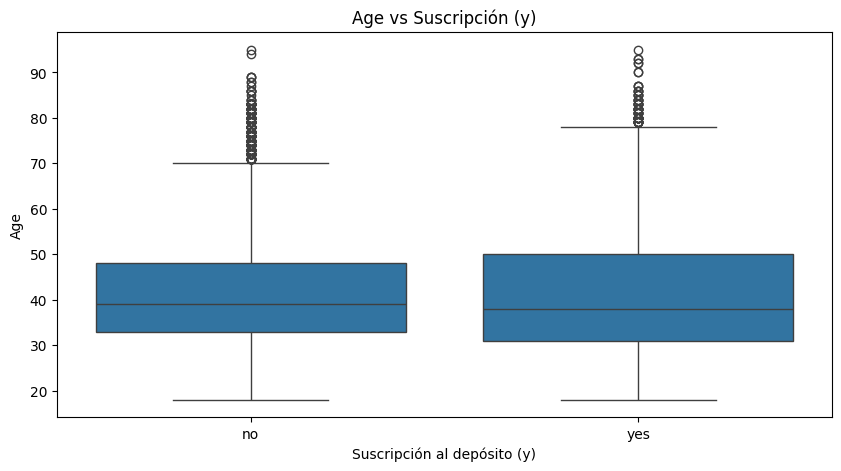

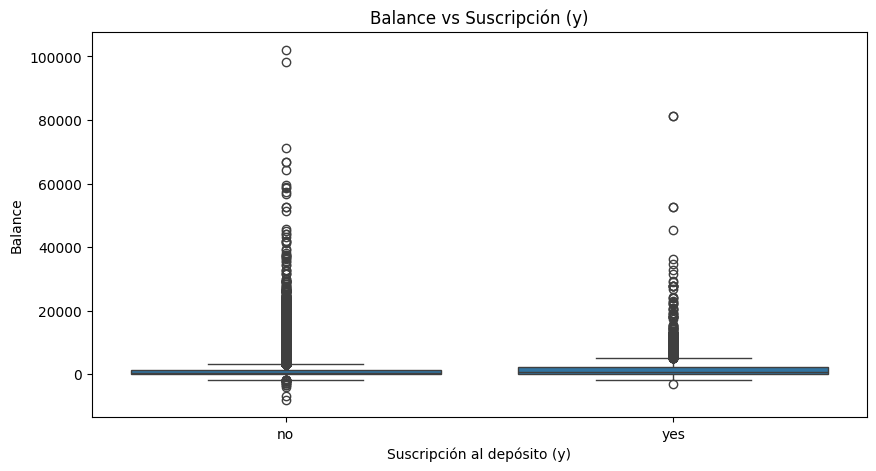

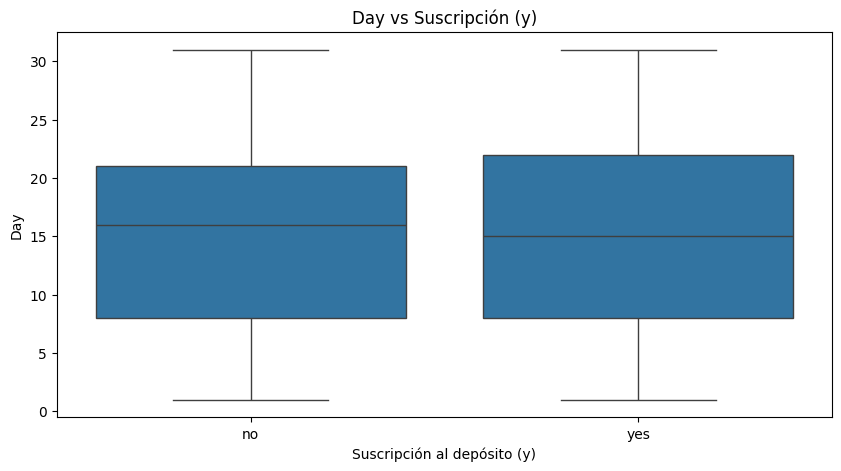

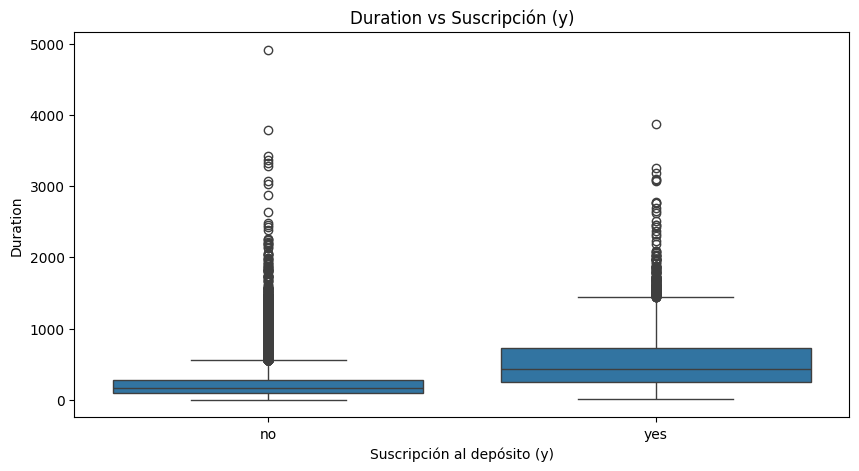

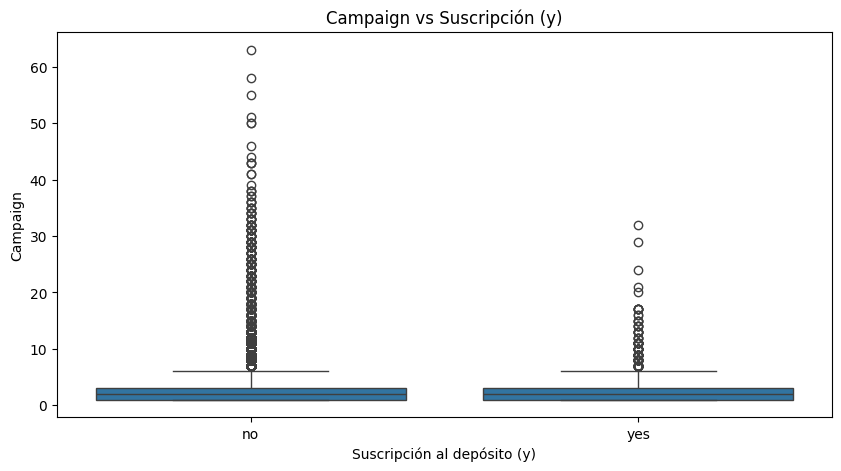

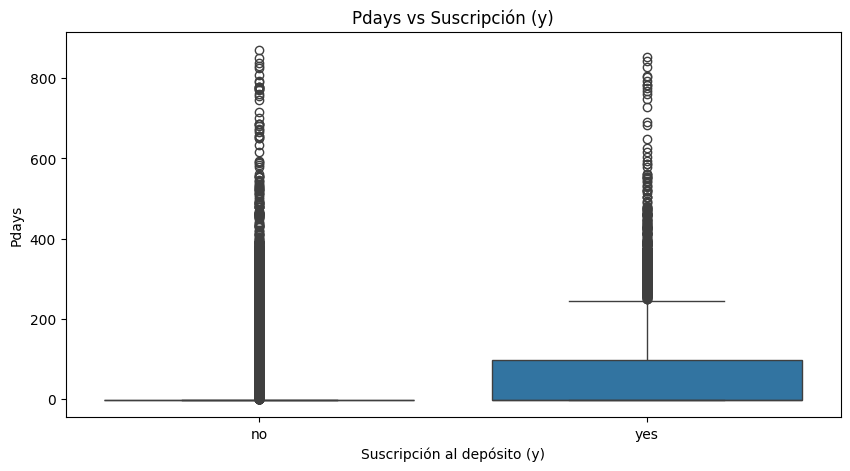

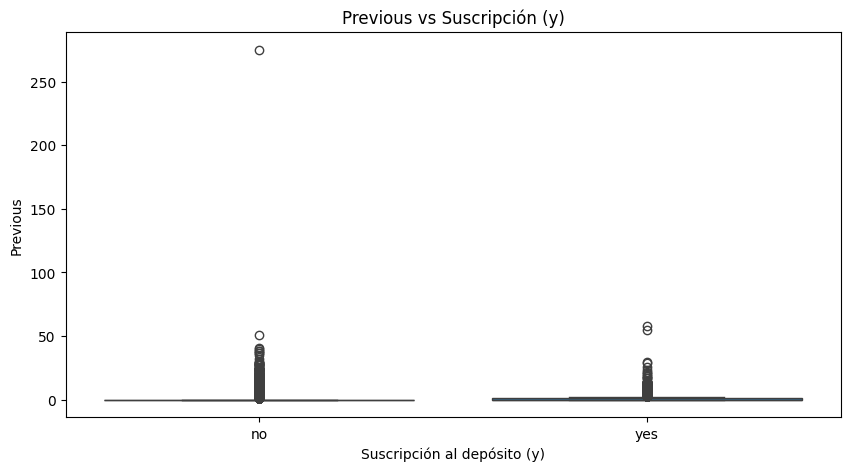

In [16]:
# Boxplots comparativos por clase de la variable objetivo
# Permiten identificar diferencias distribucionales entre clientes que suscriben vs los que no
for col in colINT:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='y', y=col, data=df01.toPandas())
    plt.title(f"{col.capitalize()} vs Suscripción (y)")
    plt.xlabel("Suscripción al depósito (y)")
    plt.ylabel(col.capitalize())
    plt.show()


> **Análisis**: La variable `duration` (duración de la llamada en segundos) muestra la diferencia más pronunciada entre ambas clases: los clientes que suscribieron el depósito tuvieron llamadas significativamente más largas en promedio. Esto tiene sentido intuitivo — una conversación más larga indica mayor interés del cliente. Sin embargo, es importante notar que `duration` es conocida *post-hoc* (solo se conoce después de realizar la llamada), por lo que su inclusión en un modelo de predicción en tiempo real podría ser problemática.


## 3.7 Análisis de Correlación entre Variables Numéricas

### 3.7.1 Preparación del Vector de Características Numéricas

Para calcular la matriz de correlación en PySpark se requiere que los datos estén en formato de **vector denso**. Se utiliza `VectorAssembler` para consolidar todas las variables numéricas — incluyendo la variable objetivo codificada numéricamente — en una única columna vectorial llamada `features`.


In [17]:
# Subconjunto de variables numéricas + variable objetivo
colNum = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Se crea un DataFrame auxiliar con las variables numéricas y 'y' codificada como 0/1
dfauxNum = df01.select(colNum + ['y'])
# Codificación binaria de la variable objetivo: yes=1, no=0
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == 'yes', 1).otherwise(0))
dfauxNum.show(5)


+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [18]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

# VectorAssembler: consolidación de columnas numéricas en un único vector 'features'
# Requerido por el módulo de estadística distribuida de PySpark
ensamblador = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
dfNumVector = ensamblador.transform(dfauxNum).select('features')


### 3.7.2 Matriz de Correlación de Pearson

La **correlación de Pearson** mide la fuerza y dirección de la relación lineal entre pares de variables. Los valores oscilan entre -1 (correlación negativa perfecta) y +1 (correlación positiva perfecta). En el contexto del modelado predictivo, valores de correlación altos entre variables predictoras (multicolinealidad) pueden afectar negativamente la estabilidad de ciertos modelos, especialmente la Regresión Logística.


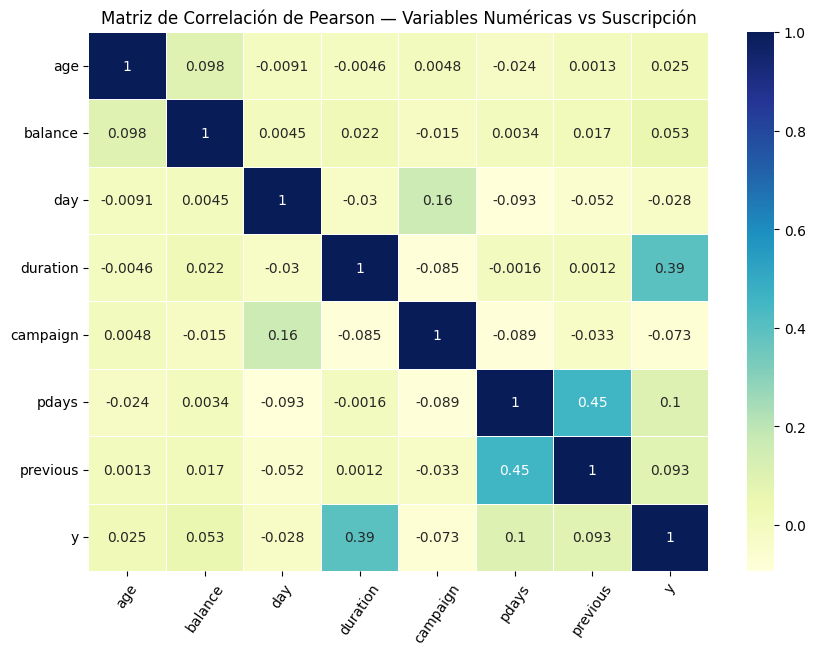

In [19]:
# Cálculo de la matriz de correlación de Pearson usando el módulo distribuido de Spark
matrizCorr = Correlation.corr(dfNumVector, 'features').head()

# Conversión del vector de correlación a array de NumPy para graficar
vectorCorr = matrizCorr[0].toArray()

# DataFrame de pandas con los nombres de columna para el mapa de calor
dfCorrelation = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

# Mapa de calor (heatmap) de correlación
plt.figure(figsize=(10, 7))
sns.heatmap(dfCorrelation,
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5)
plt.title("Matriz de Correlación de Pearson — Variables Numéricas vs Suscripción")
plt.xticks(rotation=55)
plt.yticks(rotation=0)
plt.show()


> **Análisis**: La matriz de correlación revela que las variables numéricas presentan, en general, **bajas correlaciones entre sí**, lo que es favorable para el modelado (ausencia de multicolinealidad severa). La variable `duration` muestra la correlación positiva más alta con `y`, confirmando lo observado en los boxplots. Por otro lado, `pdays` y `previous` presentan una correlación positiva moderada entre ellas, lo cual es coherente: ambas capturan información sobre el historial de contacto previo con el cliente.


### 3.7.3 Pairplot — Relaciones Bivariadas

El *pairplot* muestra simultáneamente las distribuciones univariadas (diagonal) y las relaciones bivariadas (fuera de diagonal) de todas las variables numéricas, coloreadas por la variable objetivo `y`. Esta visualización permite identificar patrones de separabilidad entre las dos clases y posibles transformaciones necesarias.


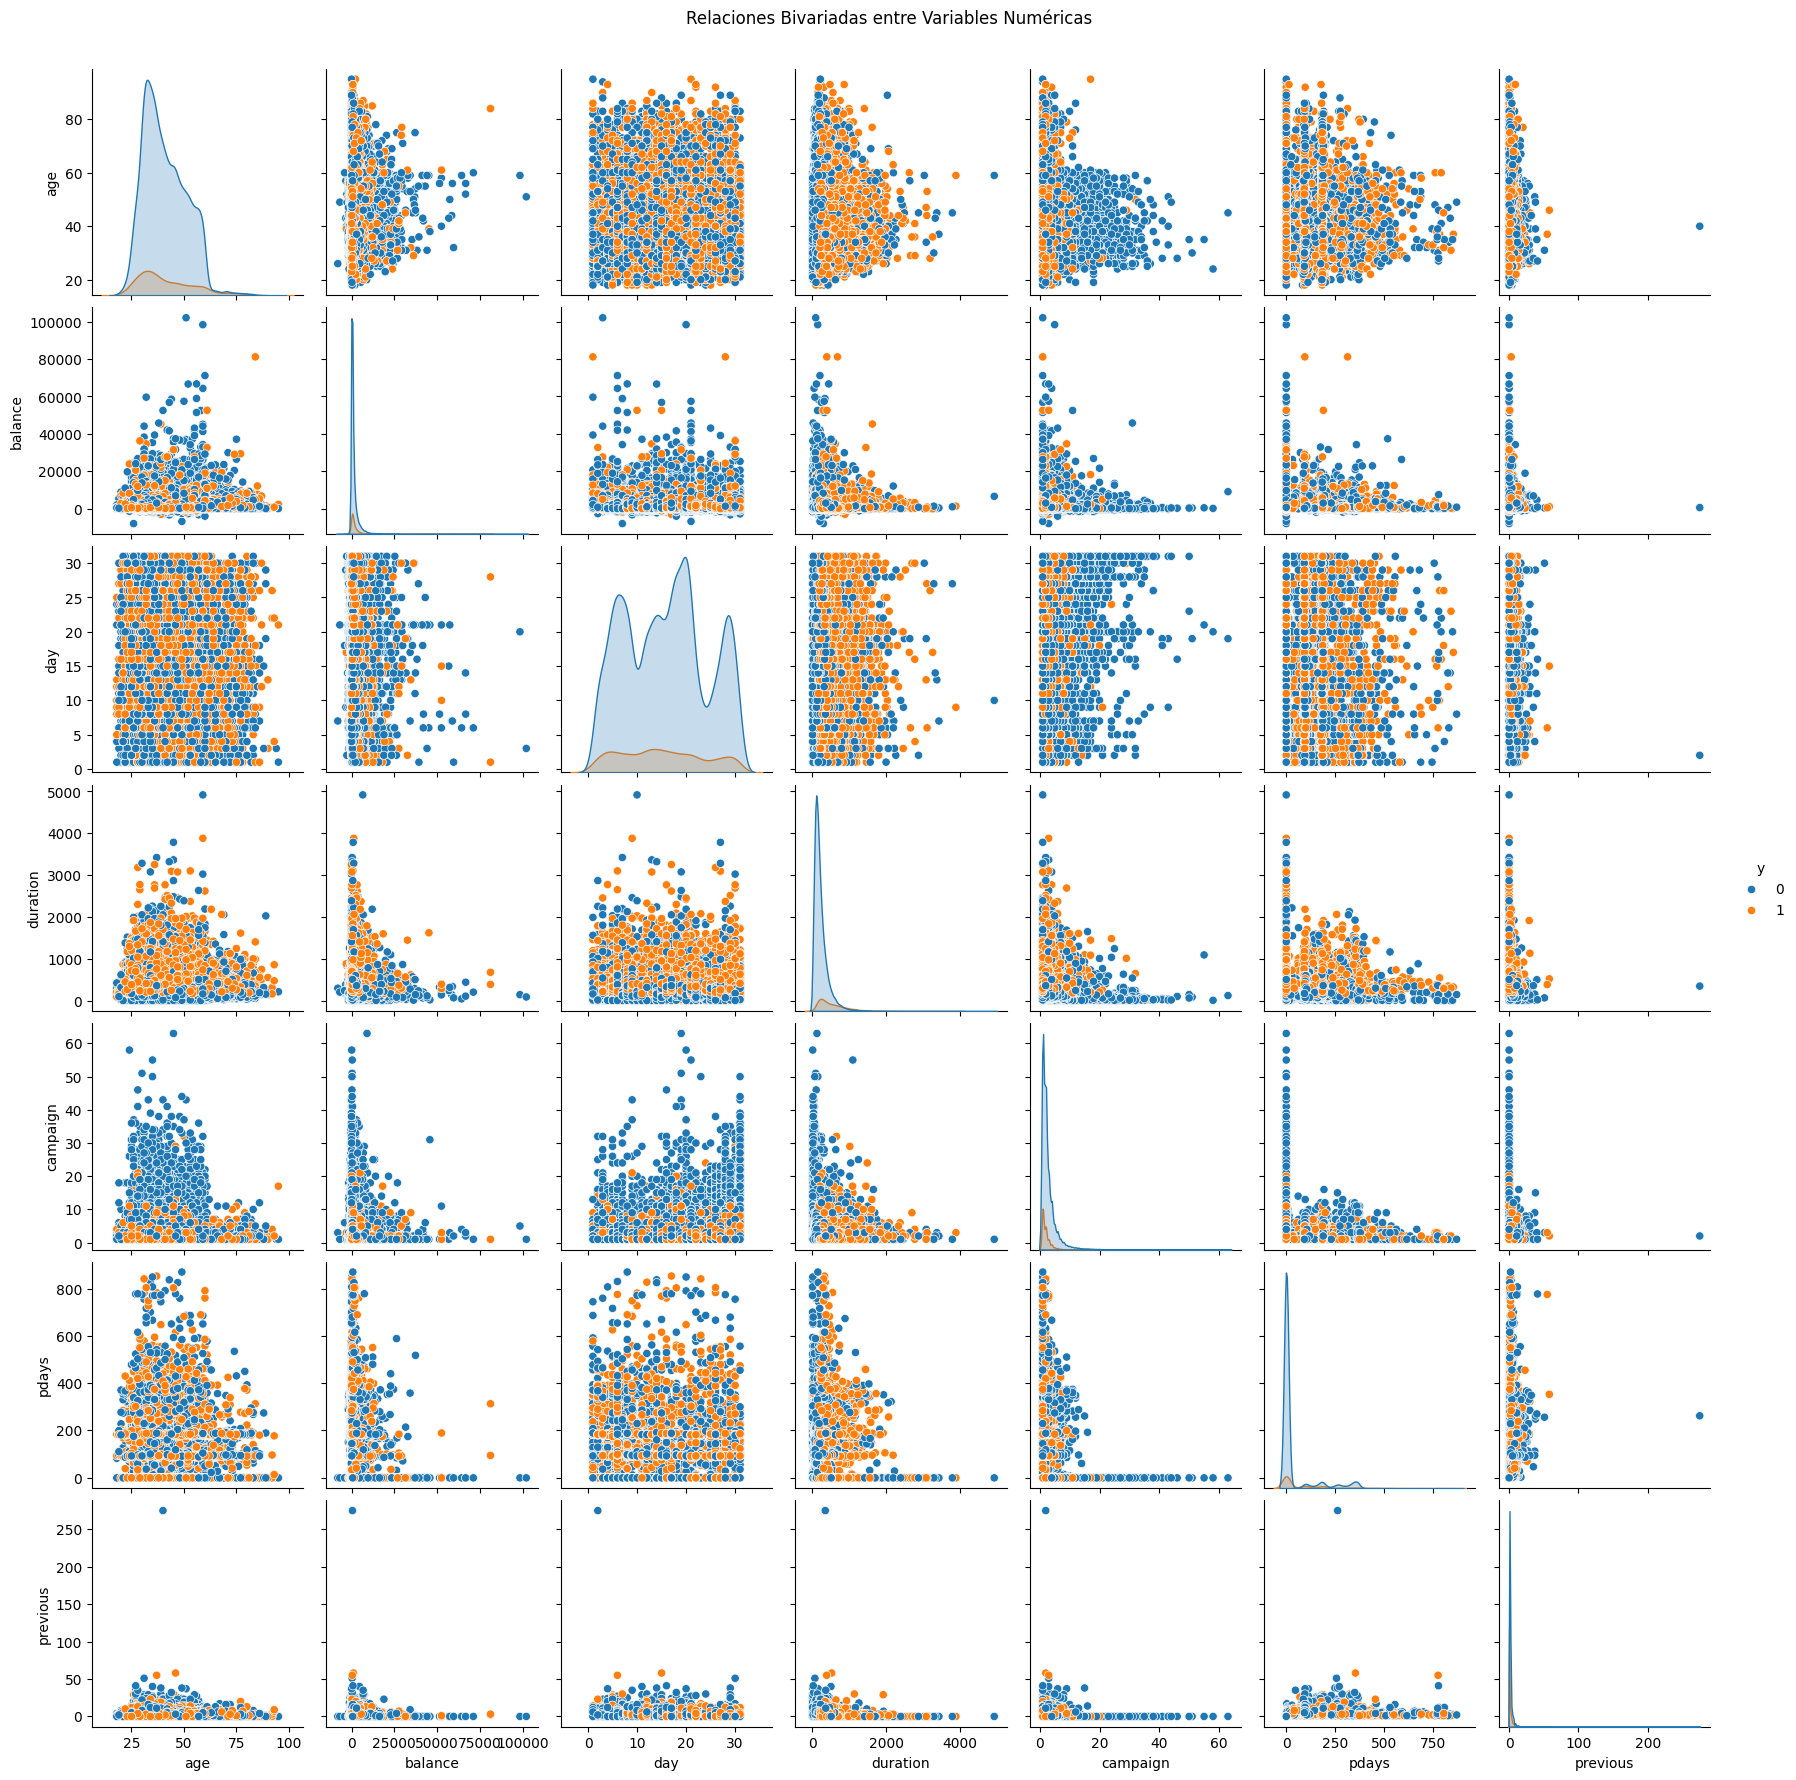

In [20]:
# Pairplot: visualización de relaciones bivariadas coloreadas por la variable objetivo
# Nota: operación costosa — requiere colectar todos los datos al driver
sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y')
plt.suptitle("Relaciones Bivariadas entre Variables Numéricas", y=1.02)
plt.show()


> **Análisis**: El pairplot confirma la ausencia de separabilidad lineal clara entre las clases en el espacio de variables numéricas. La superposición de las distribuciones de las clases `0` (no suscribió) y `1` (suscribió) indica que se requieren modelos capaces de capturar relaciones no lineales, como los árboles de decisión, Random Forest o Gradient Boosted Trees, que se entrenarán en secciones posteriores.


## 3.8 Análisis de Variables Categóricas Binarias — Gráficos de Torta

Las variables categóricas binarias del dataset (`default`, `housing`, `loan`) representan atributos de carácter financiero del cliente. Los gráficos de torta permiten visualizar rápidamente la proporción de cada categoría en el total de registros.


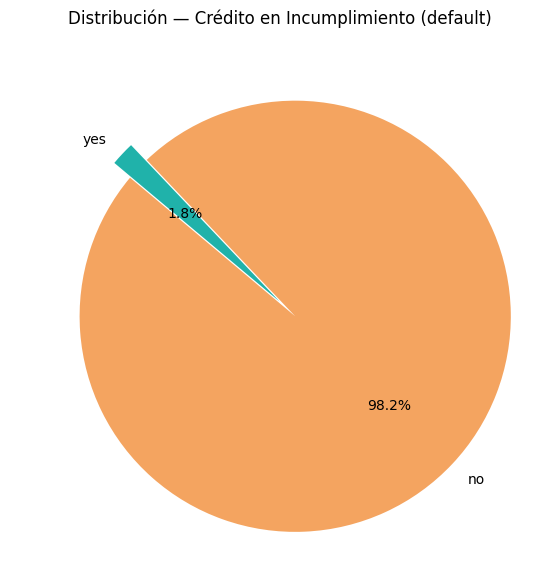

In [21]:
# Configuración de estilo compartido para los tres gráficos de torta
explode = (0.1, 0)
colors = ['sandybrown', 'lightseagreen']

# --- Gráfico 1: Distribución de Crédito en Incumplimiento (default) ---
plt.figure(figsize=(7, 7))
cantBin = df01.groupBy('default').count().toPandas()
cantBin.set_index('default')['count'].plot(
    kind='pie', explode=explode, colors=colors,
    autopct='%1.1f%%', startangle=140
)
plt.title('Distribución — Crédito en Incumplimiento (default)')
plt.ylabel('')
plt.show()


> **Análisis**: La variable `default` (crédito en incumplimiento) muestra una distribución extremadamente sesgada hacia `no`, con apenas un ~2% de clientes en mora. Esta baja incidencia reduce significativamente el poder discriminante de esta variable en los modelos de clasificación.


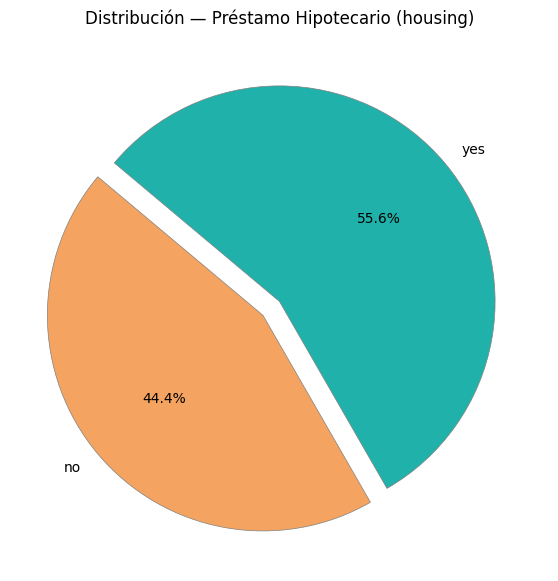

In [22]:
# --- Gráfico 2: Distribución de Préstamo Hipotecario (housing) ---
plt.figure(figsize=(7, 7))
cantBin = df01.groupBy('housing').count().toPandas()
cantBin.set_index('housing')['count'].plot(
    kind='pie', explode=explode, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'gray', 'linewidth': 0.5}
)
plt.title('Distribución — Préstamo Hipotecario (housing)')
plt.ylabel('')
plt.show()


> **Análisis**: La variable `housing` presenta una distribución más equilibrada (~56% con préstamo hipotecario vs ~44% sin él). Tener una hipoteca activa puede ser un indicador de compromiso financiero del cliente y, potencialmente, de menor propensión a adquirir nuevos productos bancarios.


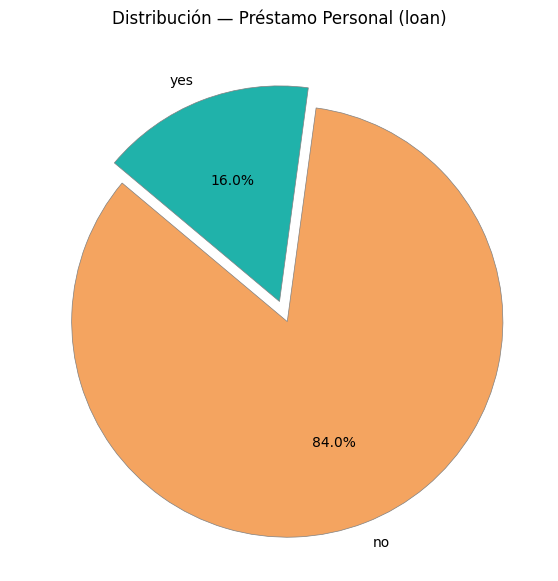

In [23]:
# --- Gráfico 3: Distribución de Préstamo Personal (loan) ---
plt.figure(figsize=(7, 7))
cantBin = df01.groupBy('loan').count().toPandas()
cantBin.set_index('loan')['count'].plot(
    kind='pie', explode=explode, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'gray', 'linewidth': 0.5}
)
plt.title('Distribución — Préstamo Personal (loan)')
plt.ylabel('')
plt.show()


> **Análisis**: La variable `loan` (préstamo personal) muestra que aproximadamente el 84% de los clientes no tiene préstamos personales activos. Al igual que `default`, la baja variabilidad limita su aporte predictivo individual, aunque puede generar interacciones relevantes con otras variables en modelos de conjunto.


## 3.9 Distribución de Variables Categóricas Multidimensionales

Las variables categóricas con múltiples categorías (`job`, `marital`, `month`, `education`, `contact`, `poutcome`) requieren un análisis de barras para comprender la representación de cada categoría en el dataset. Una distribución muy desigual entre categorías puede ser relevante para la etapa de codificación (One-Hot Encoding).


<Figure size 800x600 with 0 Axes>

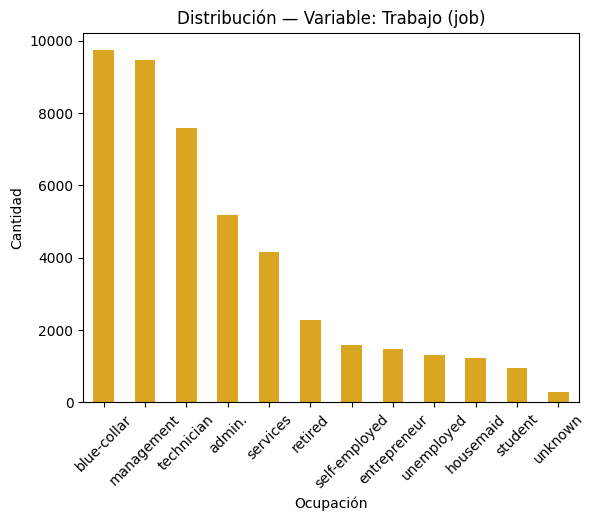

In [24]:
# Distribución de la variable 'job' (ocupación del cliente)
cantMulti = df01.groupBy('job').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='job', y='count', legend=None, color='goldenrod')
plt.xlabel('Ocupación')
plt.ylabel('Cantidad')
plt.title("Distribución — Variable: Trabajo (job)")
plt.xticks(rotation=45)
plt.show()


> **Análisis**: Las categorías más frecuentes son `management`, `blue-collar` y `technician`, lo cual refleja la composición laboral típica de una muestra bancaria. La categoría `unknown` representa un pequeño porcentaje de registros con ocupación no registrada.


<Figure size 800x600 with 0 Axes>

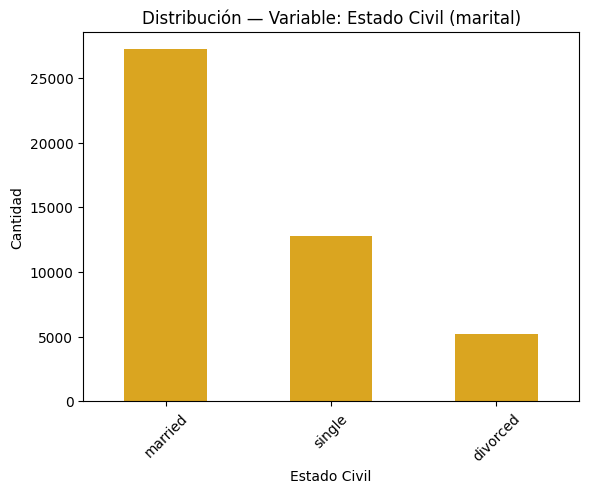

In [25]:
# Distribución de la variable 'marital' (estado civil)
cantMulti = df01.groupBy('marital').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='marital', y='count', legend=None, color='goldenrod')
plt.xlabel('Estado Civil')
plt.ylabel('Cantidad')
plt.title("Distribución — Variable: Estado Civil (marital)")
plt.xticks(rotation=45)
plt.show()


> **Análisis**: La mayoría de los clientes son casados (`married`), seguidos de solteros (`single`) y divorciados (`divorced`). El estado civil puede estar correlacionado con el nivel de ingresos y la estabilidad financiera, factores que influyen en la disposición a invertir en depósitos a plazo.


<Figure size 800x600 with 0 Axes>

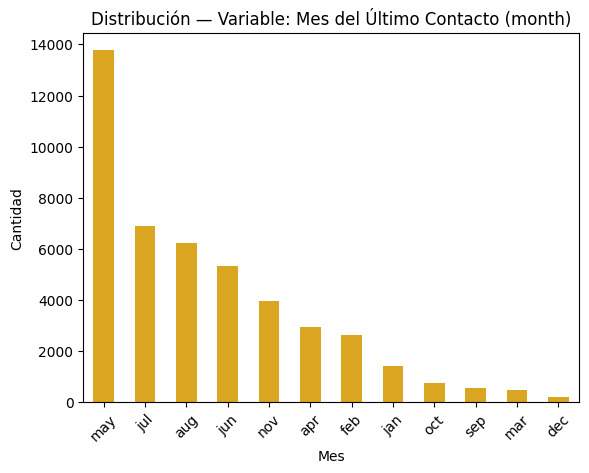

In [26]:
# Distribución de la variable 'month' (mes del último contacto)
cantMulti = df01.groupBy('month').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='month', y='count', legend=None, color='goldenrod')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.title("Distribución — Variable: Mes del Último Contacto (month)")
plt.xticks(rotation=45)
plt.show()


> **Análisis**: Los meses con mayor actividad de contacto son `may`, `jul` y `aug`, lo que sugiere que las campañas de marketing se intensificaron durante la primavera y el verano europeo. Esta estacionalidad puede ser una característica predictiva relevante.


<Figure size 800x600 with 0 Axes>

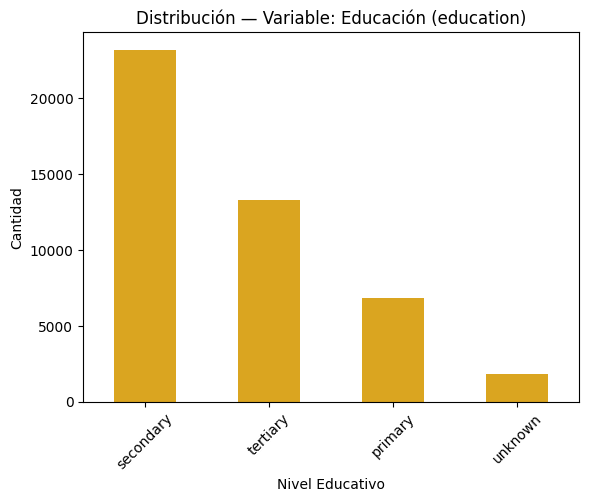

In [27]:
# Distribución de la variable 'education' (nivel educativo)
cantMulti = df01.groupBy('education').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='education', y='count', legend=None, color='goldenrod')
plt.xlabel('Nivel Educativo')
plt.ylabel('Cantidad')
plt.title("Distribución — Variable: Educación (education)")
plt.xticks(rotation=45)
plt.show()


> **Análisis**: El nivel educativo `secondary` (secundaria) es el más frecuente, seguido de `tertiary` (universitaria). El nivel educativo es un proxy habitual del nivel socioeconómico y puede influir en la receptividad del cliente a productos de inversión.


<Figure size 800x600 with 0 Axes>

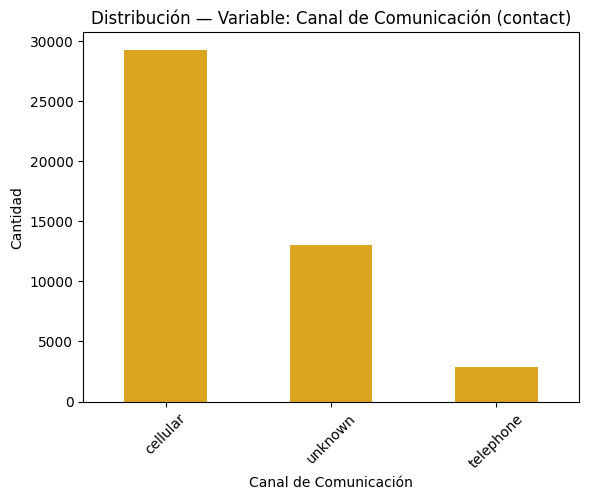

In [28]:
# Distribución de la variable 'contact' (canal de comunicación)
cantMulti = df01.groupBy('contact').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='contact', y='count', legend=None, color='goldenrod')
plt.xlabel('Canal de Comunicación')
plt.ylabel('Cantidad')
plt.title("Distribución — Variable: Canal de Comunicación (contact)")
plt.xticks(rotation=45)
plt.show()


> **Análisis**: El canal `cellular` (teléfono celular) es el medio de contacto predominante, mientras que una porción importante de registros tiene `unknown` como canal. La ausencia de información sobre el canal puede indicar datos de campañas más antiguas donde no se registraba esta información.


<Figure size 800x600 with 0 Axes>

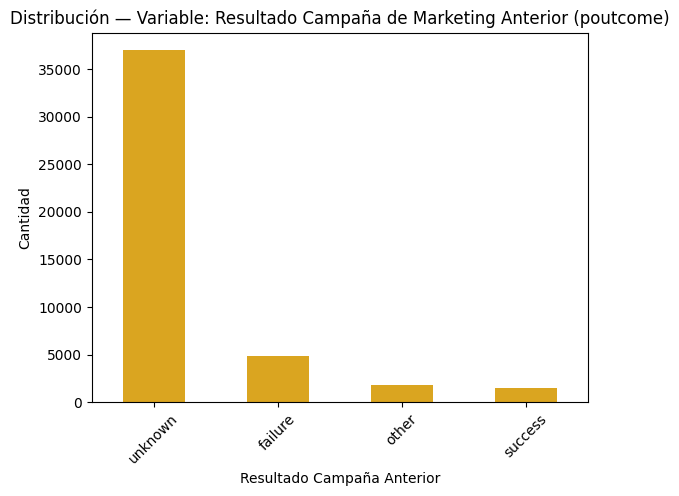

In [29]:
# Distribución de la variable 'poutcome' (resultado de la campaña previa)
cantMulti = df01.groupBy('poutcome').count().toPandas()
cantMulti = cantMulti.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
cantMulti.plot(kind='bar', x='poutcome', y='count', legend=None, color='goldenrod')
plt.xlabel('Resultado Campaña Anterior')
plt.ylabel('Cantidad')
plt.title("Distribución — Variable: Resultado Campaña de Marketing Anterior (poutcome)")
plt.xticks(rotation=45)
plt.show()


> **Análisis**: La gran mayoría de clientes tiene `unknown` como resultado de la campaña anterior, lo que indica que no fueron contactados previamente. Los clientes con resultado `success` en campañas anteriores son los más propensos a suscribir nuevamente — se corroborará esto en el análisis cruzado con `y`.


## 3.10 Análisis de Variables Categóricas vs Variable Objetivo `y`

Las tablas de contingencia cruzadas (*crosstabs*) permiten analizar la relación entre cada variable categórica y la variable objetivo `y`. A diferencia de los gráficos de distribución univariados, esta visualización revela qué categorías tienen **mayor propensión a la suscripción**, proporcionando evidencia cualitativa del poder discriminante de cada variable.


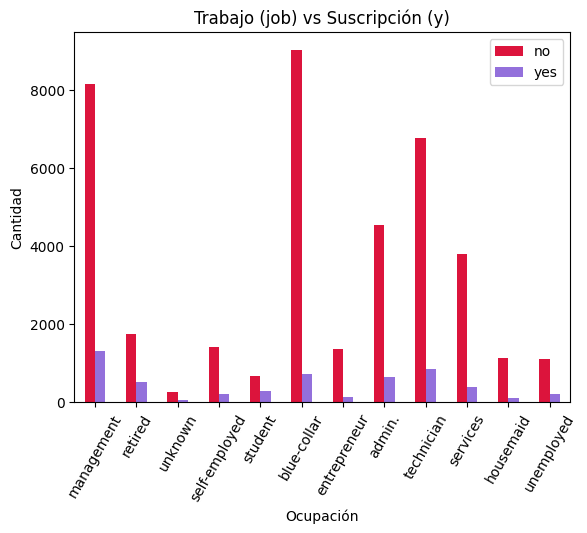

In [30]:
# Crosstab: Trabajo (job) vs Suscripción (y)
# Muestra la cantidad de suscriptores y no suscriptores por categoría de ocupación
cratabJob = df01.crosstab('job', 'y').toPandas()
cratabJob.set_index('job_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Ocupación')
plt.ylabel('Cantidad')
plt.title('Trabajo (job) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los clientes en categorías como `student` y `retired` muestran una tasa de suscripción relativamente más alta en comparación con su volumen total, posiblemente porque disponen de mayor liquidez o tiempo para considerar productos de inversión. Por el contrario, `blue-collar` tiene el menor ratio de suscripción.


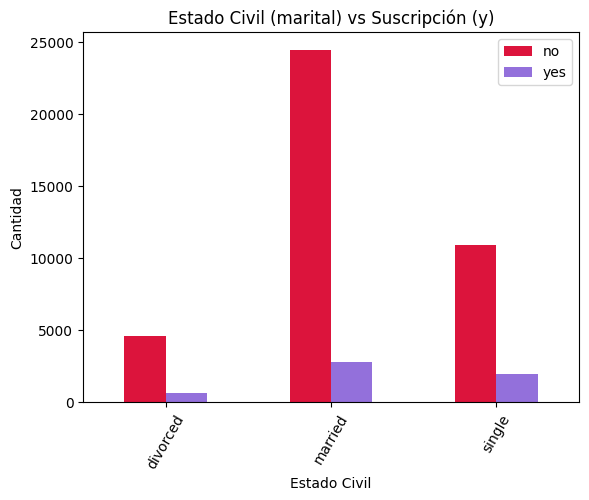

In [31]:
# Crosstab: Estado Civil (marital) vs Suscripción (y)
cratabJob = df01.crosstab('marital', 'y').toPandas()
cratabJob.set_index('marital_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Estado Civil')
plt.ylabel('Cantidad')
plt.title('Estado Civil (marital) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los clientes solteros (`single`) presentan una tasa de suscripción proporcionalmente más alta respecto a su grupo, mientras que los casados (`married`), aunque son el grupo más numeroso, tienen la tasa de conversión más baja en términos relativos.


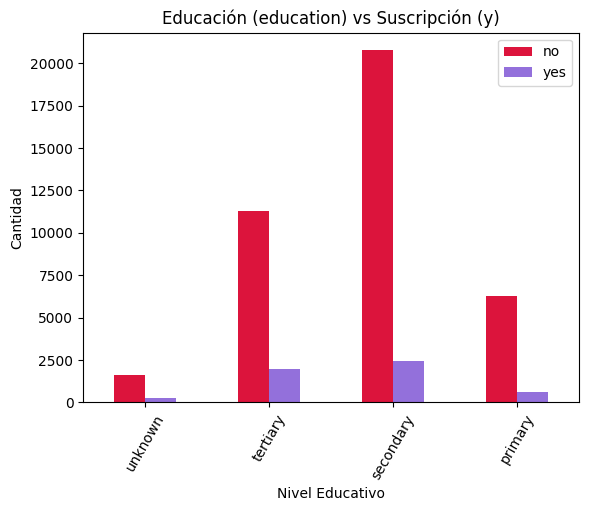

In [32]:
# Crosstab: Educación (education) vs Suscripción (y)
cratabJob = df01.crosstab('education', 'y').toPandas()
cratabJob.set_index('education_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Nivel Educativo')
plt.ylabel('Cantidad')
plt.title('Educación (education) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los clientes con nivel educativo `tertiary` (universitario) muestran la mayor tasa de suscripción relativa, lo que podría estar asociado a una mayor comprensión de los beneficios de los instrumentos de inversión a largo plazo.


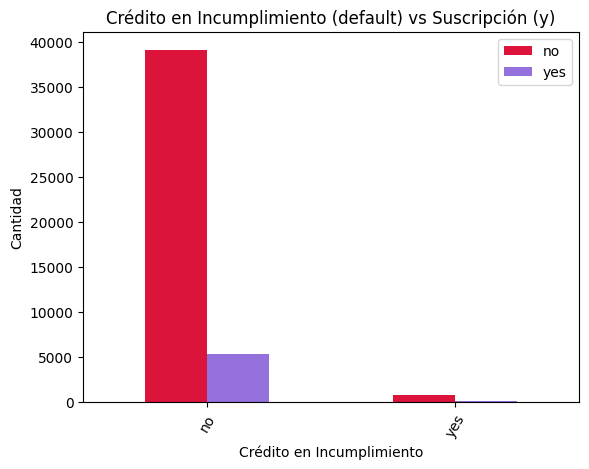

In [33]:
# Crosstab: Crédito en Incumplimiento (default) vs Suscripción (y)
cratabJob = df01.crosstab('default', 'y').toPandas()
cratabJob.set_index('default_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Crédito en Incumplimiento')
plt.ylabel('Cantidad')
plt.title('Crédito en Incumplimiento (default) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los clientes con crédito en incumplimiento (`yes`) muestran una bajísima tasa de suscripción, lo cual es coherente: un cliente en mora difícilmente destina recursos a un depósito a plazo fijo. Sin embargo, el pequeño volumen de este grupo limita las conclusiones estadísticas.


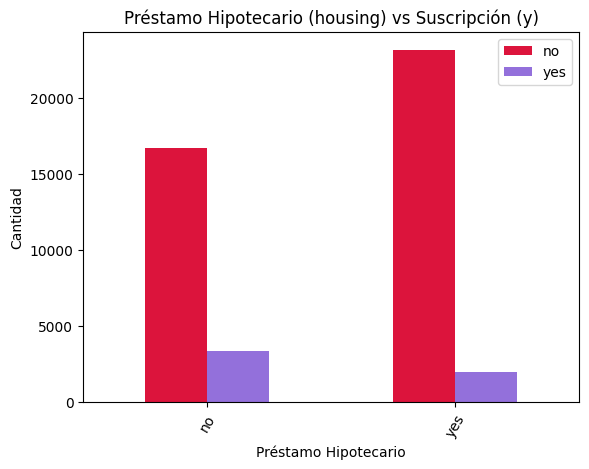

In [34]:
# Crosstab: Préstamo Hipotecario (housing) vs Suscripción (y)
cratabJob = df01.crosstab('housing', 'y').toPandas()
cratabJob.set_index('housing_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Préstamo Hipotecario')
plt.ylabel('Cantidad')
plt.title('Préstamo Hipotecario (housing) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los clientes sin préstamo hipotecario tienen una mayor tasa de conversión, posiblemente porque disponen de mayor capacidad de ahorro para destinar a un depósito a plazo.


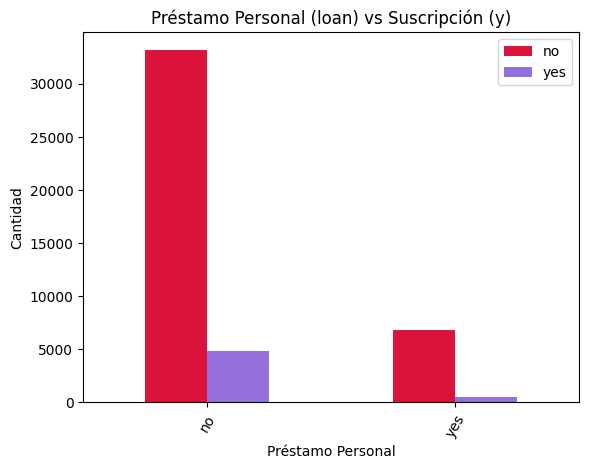

In [35]:
# Crosstab: Préstamo Personal (loan) vs Suscripción (y)
cratabJob = df01.crosstab('loan', 'y').toPandas()
cratabJob.set_index('loan_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Préstamo Personal')
plt.ylabel('Cantidad')
plt.title('Préstamo Personal (loan) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Similar al préstamo hipotecario, la ausencia de préstamos personales se asocia a una mayor tasa de suscripción. Tener compromisos de deuda activos reduce la liquidez disponible para inversiones.


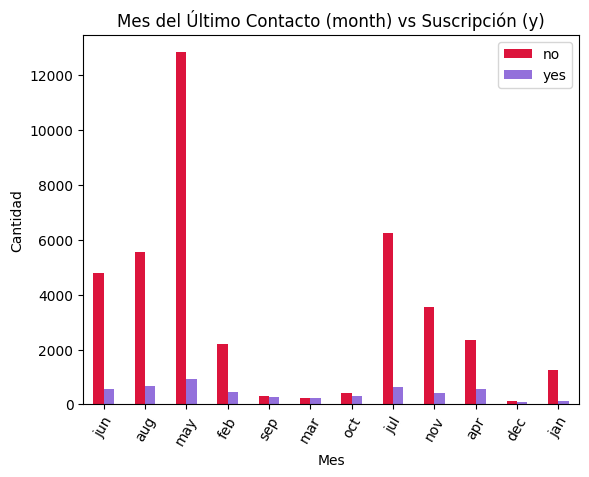

In [36]:
# Crosstab: Mes (month) vs Suscripción (y)
cratabJob = df01.crosstab('month', 'y').toPandas()
cratabJob.set_index('month_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.title('Mes del Último Contacto (month) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los meses de `mar`, `sep`, `oct` y `dec` presentan las tasas de conversión más altas en términos relativos, aunque el volumen de contactos en esos meses es considerablemente menor. Los meses con mayor volumen (`may`, `jul`, `aug`) tienen tasas de conversión más bajas, posiblemente por saturación de contactos.


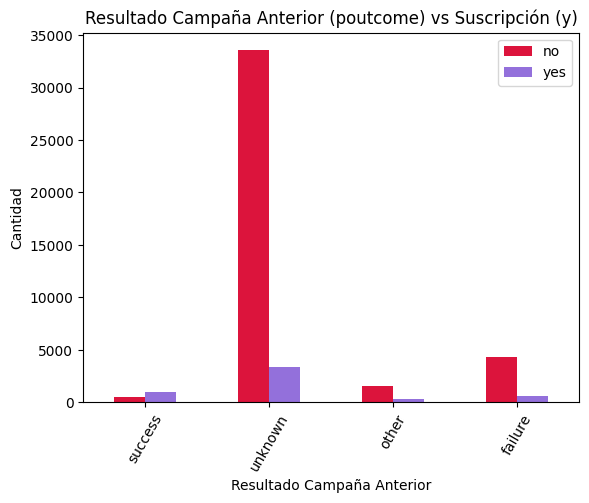

In [37]:
# Crosstab: Resultado Campaña Anterior (poutcome) vs Suscripción (y)
cratabJob = df01.crosstab('poutcome', 'y').toPandas()
cratabJob.set_index('poutcome_y').plot(kind='bar', color=['crimson', 'mediumpurple'])
plt.xlabel('Resultado Campaña Anterior')
plt.ylabel('Cantidad')
plt.title('Resultado Campaña Anterior (poutcome) vs Suscripción (y)')
plt.xticks(rotation=60)
plt.show()


> **Análisis**: Los clientes con `success` en la campaña anterior tienen la tasa de suscripción más alta con diferencia, confirmando que el historial de éxito previo es uno de los predictores más fuertes. Esto valida la importancia de las variables de campañas anteriores (`poutcome`, `previous`, `pdays`) en el modelado.


---
# 4. Calidad de los Datos


## 4.1 Verificación de Valores Nulos

La presencia de valores nulos puede afectar negativamente el entrenamiento de los modelos de Machine Learning, ya que la mayoría de los algoritmos no admiten valores faltantes de forma nativa. Se verifica columna por columna la existencia de nulos en el DataFrame.


In [38]:
# Conteo de valores nulos por columna
# Un valor nulo en PySpark es distinto de un string 'unknown' — ambos deben identificarse
for columna in df01.columns:
    cantNulos = df01.where(F.col(columna).isNull()).count()
    print(f"'{columna}': {cantNulos} valores nulos")


'age': 0 valores nulos
'job': 0 valores nulos
'marital': 0 valores nulos
'education': 0 valores nulos
'default': 0 valores nulos
'balance': 0 valores nulos
'housing': 0 valores nulos
'loan': 0 valores nulos
'contact': 0 valores nulos
'day': 0 valores nulos
'month': 0 valores nulos
'duration': 0 valores nulos
'campaign': 0 valores nulos
'pdays': 0 valores nulos
'previous': 0 valores nulos
'poutcome': 0 valores nulos
'y': 0 valores nulos


## 4.2 Análisis de Variables `pdays` y `previous`

Las variables `pdays` (días desde el último contacto en campaña anterior) y `previous` (número de contactos previos) requieren un tratamiento especial:
- **`pdays = -1`**: Convención del dataset para indicar que el cliente **nunca fue contactado** en campañas anteriores. Este valor no es un dato faltante sino una categoría codificada numéricamente.
- **`previous`**: El número de contactos previos puede contener valores extremos que podrían introducir ruido en los modelos.


In [39]:
# Análisis de pdays: clientes nunca contactados previamente (pdays = -1)
noPdays = df01.filter(F.col('pdays') == -1).count()
total = df01.count()

# Porcentaje de clientes sin contacto previo
porcNoPDAYS = (noPdays / total) * 100
print(f"Clientes sin contacto previo (pdays = -1): {noPdays} ({porcNoPDAYS:.2f}%)")
print(f"Dado que más del {porcNoPDAYS:.0f}% tiene pdays=-1, esta variable no es informativa y será eliminada.")


Clientes sin contacto previo (pdays = -1): 36954 (81.74%)
Dado que más del 82% tiene pdays=-1, esta variable no es informativa y será eliminada.


> **Análisis**: Si la gran mayoría de los registros tiene `pdays = -1`, la variable pierde capacidad discriminante. Mantenerla introduciría ruido en los modelos y el valor `-1` podría ser malinterpretado como un valor negativo real por los algoritmos. **Decisión**: se eliminará la columna `pdays` del dataset de modelado.


In [40]:
# Distribución de la variable 'previous': número de contactos previos
# Se ordena de mayor a menor para identificar posibles valores atípicos extremos
df01.groupBy("previous").count().sort("previous", ascending=False).show(20)


+--------+-----+
|previous|count|
+--------+-----+
|     275|    1|
|      58|    1|
|      55|    1|
|      51|    1|
|      41|    1|
|      40|    1|
|      38|    2|
|      37|    2|
|      35|    1|
|      32|    1|
|      30|    3|
|      29|    4|
|      28|    2|
|      27|    5|
|      26|    2|
|      25|    4|
|      24|    5|
|      23|    8|
|      22|    6|
|      21|    4|
+--------+-----+
only showing top 20 rows



> **Análisis**: La distribución de `previous` muestra que la gran mayoría de clientes fue contactado 0 veces antes. Existe un pequeño grupo con un número muy alto de contactos previos (posibles outliers) que podría distorsionar los modelos. Se define un umbral de 30 contactos para filtrar estos casos extremos.


In [41]:
# Identificación de outliers en 'previous': clientes con más de 30 contactos previos
limitePrevio = 30

cantPrevioLim = df01.filter(F.col('previous') > limitePrevio).count()
print(f"Registros con más de {limitePrevio} contactos previos (outliers): {cantPrevioLim}")
print(f"Estos registros serán eliminados por representar casos atípicos extremos.")


Registros con más de 30 contactos previos (outliers): 12
Estos registros serán eliminados por representar casos atípicos extremos.


---
# 5. Preparación y Limpieza de Datos


## 5.1 Eliminación de Registros Atípicos en `previous`

Se eliminan los registros con más de 30 contactos previos, ya que representan casos extremos que pueden introducir ruido en el proceso de entrenamiento. En un entorno de producción, estos casos podrían merecer un análisis individualizado.


In [42]:
# Filtrado: se eliminan registros con previous > 30 (outliers extremos)
df02 = df01.filter(F.col('previous') <= 30)
print(f"Registros antes del filtrado: {df01.count()}")
print(f"Registros después del filtrado: {df02.count()}")


Registros antes del filtrado: 45211
Registros después del filtrado: 45199


## 5.2 Eliminación de la Variable `pdays`

Se descarta la columna `pdays` dado que más del 80% de sus valores son `-1`, lo que significa que la variable casi no aporta información discriminante y podría confundir a los algoritmos al interpretarse como un valor numérico negativo real.


In [43]:
# Eliminación de la columna pdays: baja informatividad por alta concentración en -1
df03 = df02.drop('pdays')
print(f"Columnas resultantes: {df03.columns}")
df03.show(5)


Columnas resultantes: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'previous', 'poutcome', 'y']
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown| 

## 5.3 Balanceo de Clases — Oversampling

Para corregir el desbalance detectado en la variable objetivo `y`, se aplica la técnica de **oversampling** sobre la clase minoritaria (`yes`). El oversampling consiste en generar muestras adicionales de la clase minoritaria (con reemplazo, usando `sample(True, ...)`) hasta igualar la cantidad de registros de la clase mayoritaria.

Esta técnica es preferible a eliminar registros de la clase mayoritaria (undersampling) en este caso, ya que el dataset no es suficientemente grande como para prescindir de datos. El parámetro `seed=42` garantiza reproducibilidad del muestreo.


In [44]:
# Separación del dataset en clase mayoritaria (no) y minoritaria (yes)
dfMayorDependiente = df03.filter(df03['y'] == 'no')
dfMenorDependiente = df03.filter(df03['y'] == 'yes')

# Conteo de la clase mayoritaria para calcular la fracción de muestreo
cantMayor = dfMayorDependiente.count()

# Oversampling con reemplazo sobre la clase minoritaria
# La fracción se calcula para que la clase 'yes' iguale en tamaño a la clase 'no'
dfOverSampleMinor = dfMenorDependiente.sample(True, cantMayor / dfMenorDependiente.count(), seed=42)

# Unión de las dos clases balanceadas
df04 = dfMayorDependiente.union(dfOverSampleMinor)

print(f"Clase 'no':  {dfMayorDependiente.count()} registros")
print(f"Clase 'yes' (oversampled): {dfOverSampleMinor.count()} registros")
print(f"Total después del balanceo: {df04.count()} registros")


Clase 'no':  39912 registros
Clase 'yes' (oversampled): 40229 registros
Total después del balanceo: 80141 registros


---
# 6. Codificación y Construcción del Vector de Características


## 6.1 Codificación de Variables Categóricas

Los algoritmos de Machine Learning en PySpark requieren que las variables de entrada estén en formato numérico vectorial. Para las variables categóricas se aplica el siguiente proceso de codificación:

1. **`StringIndexer`**: Convierte cada categoría string en un índice numérico (0, 1, 2...), ordenado por frecuencia de aparición.
2. **`OneHotEncoder`**: Transforma el índice en un vector binario disperso (*sparse vector*), donde solo la posición correspondiente a la categoría activa tiene valor 1. Esto evita que el modelo asuma un orden entre categorías.

Este proceso se encadena en un **Pipeline** de Spark ML, que garantiza que las mismas transformaciones se apliquen de forma consistente tanto en entrenamiento como en inferencia.


In [45]:
# Definición de columnas categóricas que requieren codificación
CATEG_col = ['job', 'marital', 'education', 'default', 'month', 'housing', 'loan', 'contact', 'poutcome']

# Lista de etapas del pipeline ML
etapas = []

for colCategorie in CATEG_col:
    # StringIndexer: string → índice numérico (ordenado por frecuencia)
    indexer = StringIndexer(inputCol=colCategorie, outputCol=colCategorie + 'x')
    # OneHotEncoder: índice → vector binario disperso (evita ordinalidad artificial)
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[colCategorie + '_oneHot'])
    etapas += [indexer, encoder]


In [46]:
# StringIndexer para la variable objetivo 'y'
# stringOrderType='alphabetAsc': 'no'=0, 'yes'=1 (orden alfabético ascendente)
etiqueta = StringIndexer(inputCol='y', outputCol='label', stringOrderType="alphabetAsc")
etapas += [etiqueta]


## 6.2 Ensamblaje del Vector de Características

El `VectorAssembler` consolida todas las variables codificadas (vectores One-Hot de categóricas + variables numéricas) en un único vector denso llamado `features`. Este formato es el requerido por todos los algoritmos de Spark MLlib.


In [47]:
# Variables numéricas que se incluyen directamente en el vector (sin codificación adicional)
NUMER_col = ['age', 'balance', 'duration', 'day', 'campaign', 'previous']

# Lista de columnas de entrada al VectorAssembler:
# vectores One-Hot de categóricas + variables numéricas
entradaEnsamblada = [c + '_oneHot' for c in CATEG_col] + NUMER_col
print("Características incluidas en el vector de entrada:")
print(entradaEnsamblada)


Características incluidas en el vector de entrada:
['job_oneHot', 'marital_oneHot', 'education_oneHot', 'default_oneHot', 'month_oneHot', 'housing_oneHot', 'loan_oneHot', 'contact_oneHot', 'poutcome_oneHot', 'age', 'balance', 'duration', 'day', 'campaign', 'previous']


In [48]:
# VectorAssembler: unificación de todas las características en el vector 'features'
VectorEnsamblado = VectorAssembler(inputCols=entradaEnsamblada, outputCol='features')
etapas += [VectorEnsamblado]


## 6.3 Ejecución del Pipeline y Persistencia

Se ejecuta el pipeline completo sobre el dataset balanceado `df04`. El modelo del pipeline se guarda en disco para permitir su reutilización en escenarios de *streaming* o inferencia en tiempo real sin necesidad de reentrenar las etapas de preprocesamiento.


In [49]:
# Construcción y ajuste del pipeline completo sobre el dataset balanceado
pipeline = Pipeline(stages=etapas)
pipelineModel = pipeline.fit(df04)

# Persistencia del pipeline entrenado: útil para inferencia en streaming o batch posterior
pipelineModel.write().overwrite().save(path='modeloPipeline')

# Aplicación de las transformaciones al dataset completo
df05 = pipelineModel.transform(df04)


In [50]:
# Esquema resultante tras la aplicación del pipeline
df05.printSchema()


root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)
 |-- jobx: double (nullable = false)
 |-- job_oneHot: vector (nullable = true)
 |-- maritalx: double (nullable = false)
 |-- marital_oneHot: vector (nullable = true)
 |-- educationx: double (nullable = false)
 |-- education_oneHot: vector (nullable = true)
 |-- defaultx: double (nullable = false)
 |-- default_oneHot: vector (nullable = true)
 |-- monthx: double (nullable = false)

In [51]:
# Vista previa del DataFrame transformado
df05.show(5)


+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+-------------+--------+--------------+---------+---------------+-----+--------------------+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|previous|poutcome|  y|jobx|    job_oneHot|maritalx|marital_oneHot|educationx|education_oneHot|defaultx|default_oneHot|monthx|  month_oneHot|housingx|housing_oneHot|loanx|  loan_oneHot|contactx|contact_oneHot|poutcomex|poutcome_oneHot|label|            features|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+--------+--------+---+----+--------------+--------+--------------+----------+----------------+--------+--------------+------+--------------+--------+--------------+-----+---

In [52]:
# Selección solo de las columnas requeridas para el modelado: label y features
df06 = df05.select("label", "features")
df06.first()


Row(label=0.0, features=SparseVector(41, {0: 1.0, 11: 1.0, 14: 1.0, 16: 1.0, 17: 1.0, 29: 1.0, 31: 1.0, 32: 1.0, 35: 58.0, 36: 2143.0, 37: 261.0, 38: 5.0, 39: 1.0}))

In [53]:
# Verificación del esquema final: label (double) + features (vector)
df06.printSchema()


root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)



## 6.4 Persistencia en Formato Parquet

El DataFrame final se almacena en formato **Parquet** en HDFS. Parquet es un formato columnar binario optimizado para lecturas analíticas y altamente compatible con el ecosistema Hadoop/Spark. Su estructura por columnas permite a Spark leer únicamente las columnas necesarias para cada operación, reduciendo significativamente el I/O de disco.


In [54]:
# Escritura del dataset vectorizado en formato Parquet en HDFS
# mode='overwrite': sobreescribe si ya existe (útil para re-ejecuciones del notebook)
df06.write.mode("overwrite").parquet("/Almacen/output.parquet")


In [55]:
# Lectura del archivo Parquet para verificar integridad del almacenamiento
df07 = sparkBeltran.read.parquet("/Almacen/output.parquet")
df07.show(2)


+-----+--------------------+
|label|            features|
+-----+--------------------+
|  0.0|(41,[0,11,14,16,1...|
|  0.0|(41,[2,12,13,16,1...|
+-----+--------------------+
only showing top 2 rows



---
# 7. Modelización — Construcción y Entrenamiento de Modelos


## 7.1 División del Dataset en Entrenamiento y Prueba

Se divide el dataset vectorizado en dos subconjuntos:
- **Entrenamiento (80%)**: utilizado para ajustar los parámetros de cada modelo.
- **Prueba (20%)**: reservado exclusivamente para evaluar el rendimiento del modelo sobre datos no vistos.

El parámetro `seed=4321` garantiza reproducibilidad en la partición. Es fundamental que el conjunto de prueba permanezca **completamente aislado** durante el entrenamiento para obtener estimaciones imparciales del rendimiento.


In [56]:
# División aleatoria: 80% entrenamiento, 20% prueba
trainData, testData = df07.randomSplit([.8, .2], seed=4321)

print(f"Registros en conjunto de entrenamiento: {trainData.count()}")
print(f"Registros en conjunto de prueba:        {testData.count()}")


Registros en conjunto de entrenamiento: 63993
Registros en conjunto de prueba:        16148


In [57]:
# Verificación del balanceo en el conjunto de entrenamiento
distroTrain = trainData.groupBy("label").count()
distroTrain = distroTrain.withColumn("Porcentaje", distroTrain["count"] * 100 / trainData.count())
print("Distribución de clases — Conjunto de Entrenamiento:")
distroTrain.show()


Distribución de clases — Conjunto de Entrenamiento:
+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  0.0|31885|49.82576219273983|
|  1.0|32108|50.17423780726017|
+-----+-----+-----------------+



> **Análisis**: La distribución de clases en el conjunto de entrenamiento debe reflejar el balanceo aplicado en la sección anterior (~50% por clase). Una distribución balanceada garantiza que el modelo aprenda a distinguir ambas clases con igual énfasis.


In [58]:
# Verificación del balanceo en el conjunto de prueba
distroTest = testData.groupBy("label").count()
distroTest = distroTest.withColumn("Porcentaje", distroTest["count"] * 100 / testData.count())
print("Distribución de clases — Conjunto de Prueba:")
distroTest.show()


Distribución de clases — Conjunto de Prueba:
+-----+-----+-----------------+
|label|count|       Porcentaje|
+-----+-----+-----------------+
|  1.0| 8090|50.36419099794559|
|  0.0| 7973|49.63580900205441|
+-----+-----+-----------------+



> **Análisis**: El conjunto de prueba también mantiene una distribución balanceada gracias al oversampling previo. Esto permite que las métricas calculadas sobre este conjunto sean representativas de ambas clases.


## 7.2 Funciones de Visualización de Métricas

Se definen funciones auxiliares reutilizables para graficar la **Matriz de Confusión** y la **Curva ROC** de cada modelo. Centralizar estas funciones evita la duplicación de código y facilita la comparación visual entre modelos.


In [59]:
# --- Función 1: Gráfica de Matriz de Confusión ---
def plotMatConfusion(confMatrix, subtitulo):
    """
    Genera un heatmap de la matriz de confusión.
    
    Args:
        confMatrix: DataFrame de Spark con columnas 'label', 'prediction', 'count'
        subtitulo: nombre del modelo para el título del gráfico
    """
    # Conversión a pandas y reestructuración en formato pivote
    confMatrixPandas = confMatrix.toPandas()
    confMatrixPivote = confMatrixPandas.pivot(
        index='label', columns='prediction', values='count'
    ).fillna(0)
    
    # Heatmap anotado con los conteos de cada celda
    plt.figure(figsize=(5, 5))
    sns.heatmap(confMatrixPivote, annot=True, fmt='g', cmap='Blues')
    plt.suptitle(subtitulo)
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()


In [60]:
# --- Función 2: Gráfica de Curva ROC (modelos con probabilidad) ---
def plotROC(predictions, rocMetric, subtitulo):
    """
    Genera la curva ROC para modelos que producen probabilidades.
    
    Args:
        predictions: DataFrame de Spark con columnas 'probability' y 'label'
        rocMetric: valor AUC-ROC calculado con BinaryClassificationEvaluator
        subtitulo: nombre del modelo para el título
    """
    # Extracción de probabilidades de la clase positiva (índice 1)
    probs = predictions.select('probability').rdd.map(lambda row: row['probability'][1])
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    
    # Cálculo de la curva ROC con sklearn (operación en driver)
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {rocMetric:.3f})')
    # Línea de referencia: clasificador aleatorio (AUC = 0.5)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Clasificador aleatorio')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Curva ROC — Receiver Operating Characteristic')
    plt.suptitle(subtitulo)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()


---
# 7.3 Modelo 1 — Regresión Logística (LR)

La **Regresión Logística** es un modelo lineal de clasificación que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Es el modelo de referencia (*baseline*) en problemas de clasificación binaria por su interpretabilidad y eficiencia computacional.

**Parámetros**: `maxIter=10` — número máximo de iteraciones del optimizador L-BFGS.

**Supuestos**: asume linealidad entre las variables predictoras y el log-odds de la variable respuesta. Su rendimiento puede verse limitado si las relaciones entre variables son no lineales.


### 7.3.1 Entrenamiento del Modelo LR


In [61]:
from pyspark.ml.classification import LogisticRegression

# Instanciación del modelo con columnas de entrada y etiqueta
instanciaLR = LogisticRegression(featuresCol='features', labelCol='label', maxIter=10)

# Ajuste del modelo sobre los datos de entrenamiento
modeloLR = instanciaLR.fit(trainData)


26/05/25 18:50:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


### 7.3.2 Predicción sobre el Conjunto de Prueba


In [62]:
# Generación de predicciones sobre datos no vistos (conjunto de prueba)
predLR = modeloLR.transform(testData)

# Vista previa: etiqueta real, predicción y probabilidades por clase
predLR.select("label", "prediction", "probability").show(5)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.77508024046476...|
|  0.0|       0.0|[0.73761149478548...|
|  0.0|       0.0|[0.80661084539907...|
|  0.0|       0.0|[0.92651156791349...|
|  0.0|       0.0|[0.91683963352989...|
+-----+----------+--------------------+
only showing top 5 rows



### 7.3.3 Métricas de Evaluación — Modelo LR


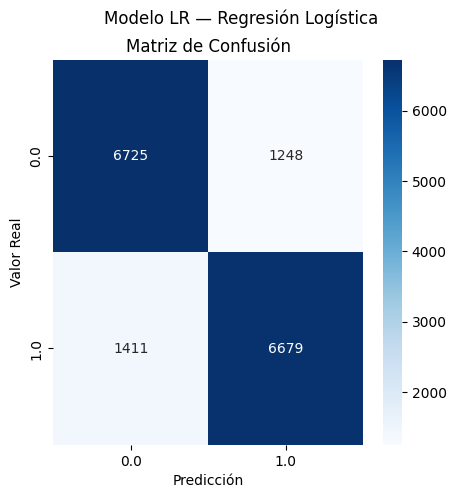

  Métricas de Rendimiento — Modelo LR — Regresión Logística
  Accuracy           : 0.8345
  Precisión (weighted): 0.8346
  Recall (weighted)  : 0.8345
  F1-Score (weighted): 0.8345
  AUC-ROC            : 0.9103
  AUC-PR             : 0.8912


In [63]:
# Evaluador para métricas de clasificación multiclase
evaluadorLR = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Generación de la matriz de confusión
primerModelo = "Modelo LR — Regresión Logística"
confMatrixLR = predLR.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixLR, primerModelo)

# Cálculo de las cuatro métricas principales
accuracyLR  = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "accuracy"})
precisionLR = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedPrecision"})
recallLR    = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "weightedRecall"})
f1ScoreLR   = evaluadorLR.evaluate(predLR, {evaluadorLR.metricName: "f1"})

# Métricas adicionales para clasificación binaria
evaluadorBinLR = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocLR     = evaluadorBinLR.evaluate(predLR)
prAucLR   = evaluadorBinLR.evaluate(predLR, {evaluadorBinLR.metricName: "areaUnderPR"})

# Reporte de métricas
print(f"{'='*45}")
print(f"  Métricas de Rendimiento — {primerModelo}")
print(f"{'='*45}")
print(f"  Accuracy           : {accuracyLR:.4f}")
print(f"  Precisión (weighted): {precisionLR:.4f}")
print(f"  Recall (weighted)  : {recallLR:.4f}")
print(f"  F1-Score (weighted): {f1ScoreLR:.4f}")
print(f"  AUC-ROC            : {rocLR:.4f}")
print(f"  AUC-PR             : {prAucLR:.4f}")
print(f"{'='*45}")


### 7.3.4 Curva ROC — Modelo LR


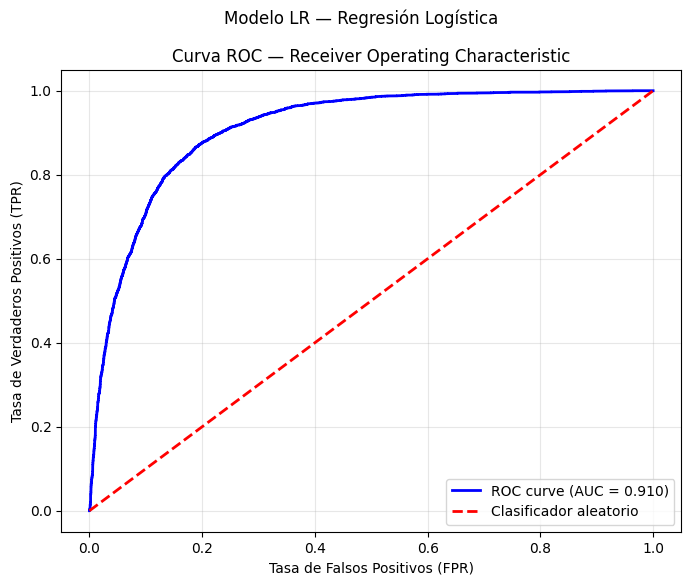

In [64]:
# Visualización de la curva ROC para el modelo de Regresión Logística
plotROC(predLR, rocLR, primerModelo)


> **Análisis**: La Regresión Logística establece el *baseline* de rendimiento. Al ser un modelo lineal, puede no capturar interacciones no lineales entre variables. El AUC-ROC obtenido indica la capacidad del modelo para discriminar entre las dos clases; valores superiores a 0.85 se consideran buenos para este tipo de problemas. El AUC-PR complementa esta evaluación en contextos de desbalance de clases.


---
# 7.4 Modelo 2 — Árbol de Decisión (DT)

El **Árbol de Decisión** es un modelo no paramétrico que divide el espacio de características mediante reglas binarias jerárquicas. Es fácilmente interpretable (puede visualizarse como un árbol de reglas) y no requiere escalado de variables. Sin embargo, los árboles profundos tienden a **sobreajustarse** (overfitting) al conjunto de entrenamiento.

**Ventajas**: alta interpretabilidad, captura relaciones no lineales, no asume normalidad.
**Limitaciones**: inestabilidad ante pequeños cambios en los datos, tendencia al overfitting.


### 7.4.1 Entrenamiento del Modelo DT


In [65]:
from pyspark.ml.classification import DecisionTreeClassifier

# Instanciación del árbol de decisión con profundidad por defecto
instanciaDT = DecisionTreeClassifier(labelCol='label', featuresCol="features")

# Ajuste del modelo
modeloDT = instanciaDT.fit(trainData)


### 7.4.2 Predicción sobre el Conjunto de Prueba


In [66]:
# Predicción sobre datos de prueba
predDT = modeloDT.transform(testData)
predDT.select("label", "prediction", "probability").show(10)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.83915174118565...|
|  0.0|       0.0|[0.83915174118565...|
|  0.0|       0.0|[0.91090236265300...|
|  0.0|       0.0|[0.91090236265300...|
|  0.0|       0.0|[0.91090236265300...|
|  0.0|       0.0|[0.83915174118565...|
|  0.0|       0.0|[0.83915174118565...|
|  0.0|       0.0|[0.83915174118565...|
|  0.0|       0.0|[0.59508660303994...|
|  0.0|       0.0|[0.83915174118565...|
+-----+----------+--------------------+
only showing top 10 rows



### 7.4.3 Métricas de Evaluación — Modelo DT


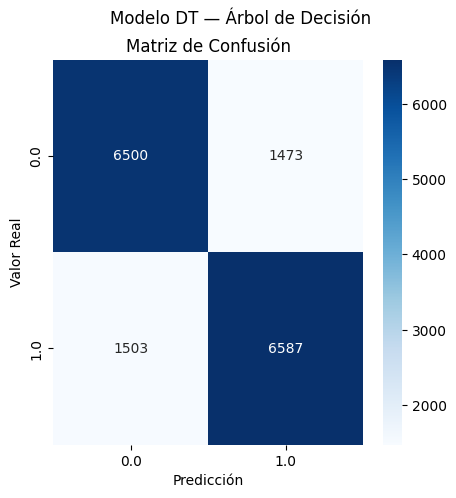

  Métricas de Rendimiento — Modelo DT — Árbol de Decisión
  Accuracy           : 0.8147
  Precisión (weighted): 0.8147
  Recall (weighted)  : 0.8147
  F1-Score (weighted): 0.8147
  AUC-ROC            : 0.6986
  AUC-PR             : 0.7493


In [67]:
evaluadorDT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Matriz de confusión
segundoModelo = "Modelo DT — Árbol de Decisión"
confMatrixDT = predDT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixDT, segundoModelo)

# Métricas de clasificación
accuracyDT  = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "accuracy"})
precisionDT = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedPrecision"})
recallDT    = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "weightedRecall"})
f1ScoreDT   = evaluadorDT.evaluate(predDT, {evaluadorDT.metricName: "f1"})

# Métricas binarias
evaluadorBinDT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocDT   = evaluadorBinDT.evaluate(predDT)
prAucDT = evaluadorBinDT.evaluate(predDT, {evaluadorBinDT.metricName: "areaUnderPR"})

print(f"{'='*45}")
print(f"  Métricas de Rendimiento — {segundoModelo}")
print(f"{'='*45}")
print(f"  Accuracy           : {accuracyDT:.4f}")
print(f"  Precisión (weighted): {precisionDT:.4f}")
print(f"  Recall (weighted)  : {recallDT:.4f}")
print(f"  F1-Score (weighted): {f1ScoreDT:.4f}")
print(f"  AUC-ROC            : {rocDT:.4f}")
print(f"  AUC-PR             : {prAucDT:.4f}")
print(f"{'='*45}")


### 7.4.4 Curva ROC — Modelo DT


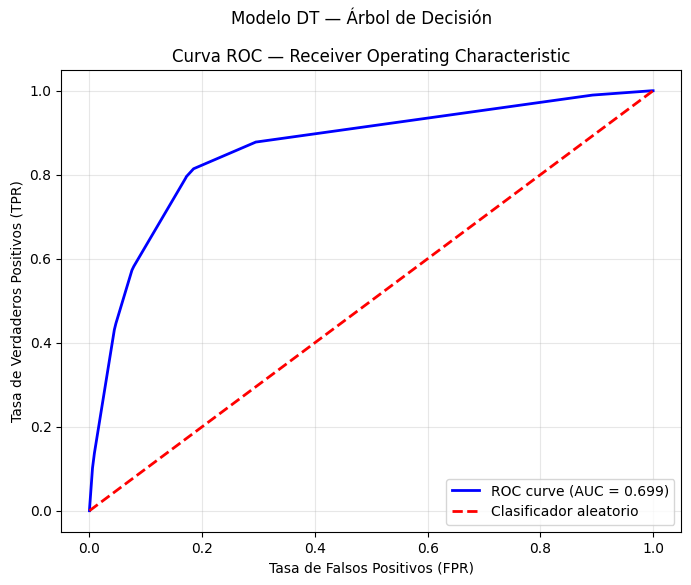

In [68]:
# Visualización de la curva ROC para el Árbol de Decisión
plotROC(predDT, rocDT, segundoModelo)


> **Análisis**: El Árbol de Decisión captura relaciones no lineales que la Regresión Logística no puede modelar, lo que generalmente se traduce en una mejora en las métricas. Sin embargo, al ser un modelo de árbol único sin regularización explícita, puede mostrar signos de sobreajuste comparado con modelos de conjunto como Random Forest o GBT.


---
# 7.5 Modelo 3 — Random Forest (RF)

El **Random Forest** es un modelo de ensamble que construye múltiples árboles de decisión (`numTrees=100`) entrenados sobre subconjuntos aleatorios de los datos y las características, combinando sus predicciones mediante votación mayoritaria. Esta aleatorización reduce el overfitting y mejora la generalización.

**Hiperparámetros clave**:
- `numTrees=100`: número de árboles en el bosque — mayor cantidad reduce la varianza pero incrementa el tiempo de entrenamiento.
- `maxDepth=5`: profundidad máxima de cada árbol — controla el overfitting.


### 7.5.1 Entrenamiento del Modelo RF


In [69]:
from pyspark.ml.classification import RandomForestClassifier

# Instanciación: 100 árboles con profundidad máxima de 5
instanciaRF = RandomForestClassifier(featuresCol='features', labelCol='label', numTrees=100, maxDepth=5)

# Entrenamiento del Random Forest (proceso paralelizable en Spark)
modeloRF = instanciaRF.fit(trainData)


### 7.5.2 Predicción sobre el Conjunto de Prueba


In [70]:
# Predicción y vista previa
predRF = modeloRF.transform(testData)
predRF.select("label", "prediction", "probability").show(5)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.68107479858438...|
|  0.0|       0.0|[0.58374491358051...|
|  0.0|       0.0|[0.72886341578200...|
|  0.0|       0.0|[0.76085556570252...|
|  0.0|       0.0|[0.75822124054335...|
+-----+----------+--------------------+
only showing top 5 rows



### 7.5.3 Métricas de Evaluación — Modelo RF


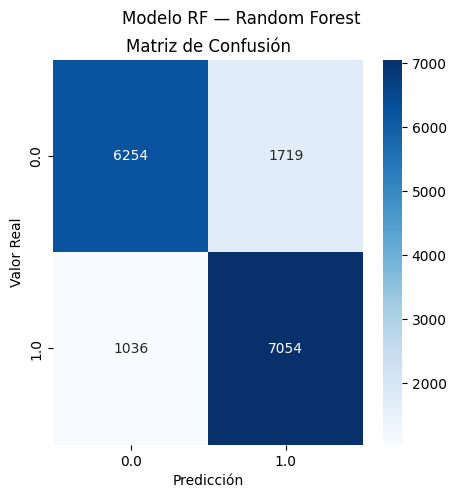

  Métricas de Rendimiento — Modelo RF — Random Forest
  Accuracy           : 0.8285
  Precisión (weighted): 0.8308
  Recall (weighted)  : 0.8285
  F1-Score (weighted): 0.8281
  AUC-ROC            : 0.9021
  AUC-PR             : 0.8849


In [71]:
evaluadorRF = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

tercerModelo = "Modelo RF — Random Forest"
confMatrixRF = predRF.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixRF, tercerModelo)

# Métricas de clasificación
accuracyRF  = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "accuracy"})
precisionRF = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedPrecision"})
recallRF    = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "weightedRecall"})
f1ScoreRF   = evaluadorRF.evaluate(predRF, {evaluadorRF.metricName: "f1"})

# Métricas binarias
evaluadorBinRF = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocRF   = evaluadorBinRF.evaluate(predRF)
prAucRF = evaluadorBinRF.evaluate(predRF, {evaluadorBinRF.metricName: "areaUnderPR"})

print(f"{'='*45}")
print(f"  Métricas de Rendimiento — {tercerModelo}")
print(f"{'='*45}")
print(f"  Accuracy           : {accuracyRF:.4f}")
print(f"  Precisión (weighted): {precisionRF:.4f}")
print(f"  Recall (weighted)  : {recallRF:.4f}")
print(f"  F1-Score (weighted): {f1ScoreRF:.4f}")
print(f"  AUC-ROC            : {rocRF:.4f}")
print(f"  AUC-PR             : {prAucRF:.4f}")
print(f"{'='*45}")


### 7.5.4 Curva ROC — Modelo RF


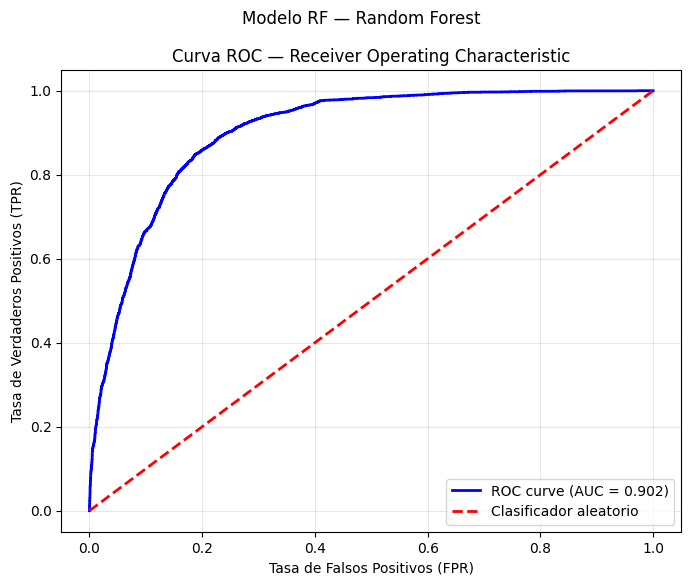

In [72]:
# Visualización de la curva ROC para Random Forest
plotROC(predRF, rocRF, tercerModelo)


> **Análisis**: Random Forest generalmente supera al Árbol de Decisión individual gracias a la reducción de varianza mediante el ensamble. La profundidad limitada (`maxDepth=5`) actúa como regularización implícita. La importancia de características calculable en RF permite identificar las variables con mayor poder predictivo en el dataset.


---
# 7.6 Modelo 4 — Gradient Boosted Tree (GBT)

El **Gradient Boosted Tree** es un modelo de ensamble de tipo *boosting*: construye árboles de forma secuencial, donde cada árbol nuevo corrige los errores del anterior minimizando una función de pérdida (en Spark ML, log-loss para clasificación binaria). A diferencia del Random Forest (que construye árboles en paralelo), GBT los construye en serie.

**Hiperparámetros clave**:
- `maxIter=10`: número de iteraciones de boosting (árboles construidos secuencialmente).
- `maxDepth=5`: profundidad de cada árbol base — menor profundidad = mayor regularización.

GBT suele ser uno de los algoritmos con mejor rendimiento en problemas tabulares de clasificación.


### 7.6.1 Entrenamiento del Modelo GBT


In [73]:
from pyspark.ml.classification import GBTClassifier

# Instanciación: 10 iteraciones de boosting con árboles de profundidad 5
instanciaGBT = GBTClassifier(featuresCol='features', labelCol='label', maxIter=10, maxDepth=5)

# Entrenamiento del GBT (proceso secuencial — más lento que RF en mismas condiciones)
modeloGBT = instanciaGBT.fit(trainData)


### 7.6.2 Predicción sobre el Conjunto de Prueba


In [74]:
# Generación de predicciones del modelo GBT
predGBT = modeloGBT.transform(testData)
predGBT.select("label", "prediction", "probability").show(5)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.88730325244549...|
|  0.0|       0.0|[0.9001819691399,...|
|  0.0|       0.0|[0.90181123138684...|
|  0.0|       0.0|[0.92404333133592...|
|  0.0|       0.0|[0.91891472828103...|
+-----+----------+--------------------+
only showing top 5 rows



### 7.6.3 Métricas de Evaluación — Modelo GBT


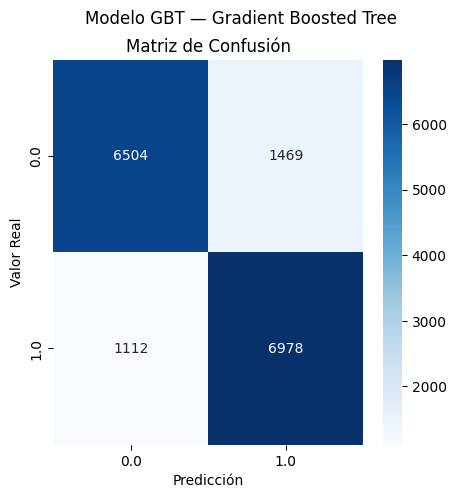

  Métricas de Rendimiento — Modelo GBT — Gradient Boosted Tree
  Accuracy           : 0.8393
  Precisión (weighted): 0.8399
  Recall (weighted)  : 0.8393
  F1-Score (weighted): 0.8392
  AUC-ROC            : 0.9148
  AUC-PR             : 0.8984


In [75]:
evaluadorGBT = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

cuartoModelo = "Modelo GBT — Gradient Boosted Tree"
confMatrixGBT = predGBT.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixGBT, cuartoModelo)

# Métricas de clasificación
accuracyGBT  = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "accuracy"})
precisionGBT = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedPrecision"})
recallGBT    = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "weightedRecall"})
f1ScoreGBT   = evaluadorGBT.evaluate(predGBT, {evaluadorGBT.metricName: "f1"})

# Métricas binarias
evaluadorBinGBT = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocGBT   = evaluadorBinGBT.evaluate(predGBT)
prAucGBT = evaluadorBinGBT.evaluate(predGBT, {evaluadorBinGBT.metricName: "areaUnderPR"})

print(f"{'='*45}")
print(f"  Métricas de Rendimiento — {cuartoModelo}")
print(f"{'='*45}")
print(f"  Accuracy           : {accuracyGBT:.4f}")
print(f"  Precisión (weighted): {precisionGBT:.4f}")
print(f"  Recall (weighted)  : {recallGBT:.4f}")
print(f"  F1-Score (weighted): {f1ScoreGBT:.4f}")
print(f"  AUC-ROC            : {rocGBT:.4f}")
print(f"  AUC-PR             : {prAucGBT:.4f}")
print(f"{'='*45}")


### 7.6.4 Curva ROC — Modelo GBT


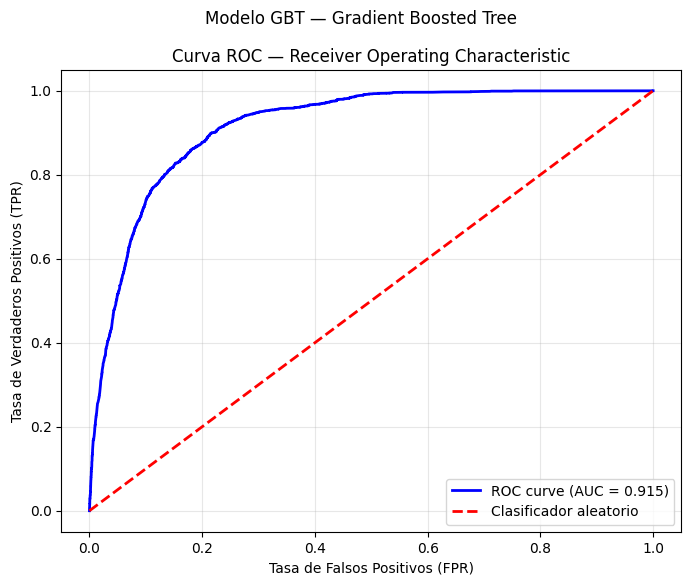

In [76]:
# Visualización de la curva ROC para el Gradient Boosted Tree
plotROC(predGBT, rocGBT, cuartoModelo)


> **Análisis**: GBT generalmente produce el mejor rendimiento entre los modelos de árbol gracias a su capacidad para minimizar iterativamente la función de pérdida. Su AUC-ROC suele ser superior al de Random Forest, especialmente en datasets con relaciones complejas entre variables. El trade-off es un mayor tiempo de entrenamiento y mayor riesgo de sobreajuste si `maxIter` es muy alto.


---
# 7.7 Modelo 5 — Máquina de Soporte Vectorial (SVM)

La **SVM lineal** (`LinearSVC` en Spark ML) busca el hiperplano de separación óptimo que maximiza el margen entre las dos clases. A diferencia de los modelos anteriores, el SVM de Spark no produce probabilidades de clase directamente, sino un valor de decisión lineal (`rawPrediction`).

**Hiperparámetros clave**:
- `maxIter=10`: número de iteraciones del optimizador.
- `regParam=0.1`: parámetro de regularización L2 — controla el balance entre margen y error de clasificación.

> **Nota técnica**: Dado que `LinearSVC` no genera la columna `probability`, la curva ROC se construye a partir de `rawPrediction` mediante una función auxiliar especializada.


### 7.7.1 Entrenamiento del Modelo SVM


In [77]:
from pyspark.ml.classification import LinearSVC

# Instanciación del SVM lineal con regularización L2 (regParam=0.1)
instanciaSVM = LinearSVC(featuresCol='features', labelCol='label', maxIter=10, regParam=0.1)

# Entrenamiento del modelo SVM
modeloSVM = instanciaSVM.fit(trainData)


### 7.7.2 Predicción sobre el Conjunto de Prueba


In [78]:
# Predicción SVM: se usa rawPrediction en lugar de probability
predSVM = modeloSVM.transform(testData)
predSVM.select("label", "prediction", "rawPrediction").show(5)


+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|  0.0|       0.0|[0.67951031405141...|
|  0.0|       0.0|[0.43770904314965...|
|  0.0|       0.0|[0.68363189885721...|
|  0.0|       0.0|[1.17249686340950...|
|  0.0|       0.0|[1.12687064231634...|
+-----+----------+--------------------+
only showing top 5 rows



### 7.7.3 Métricas de Evaluación — Modelo SVM


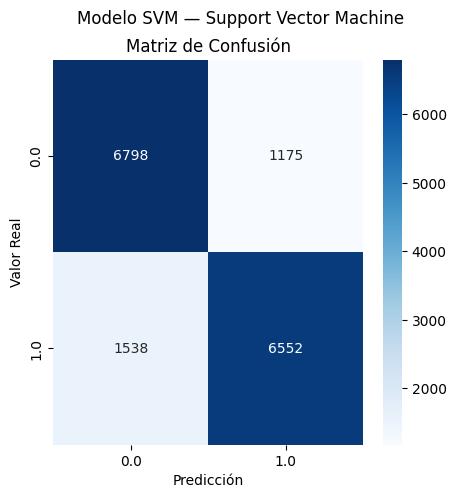

  Métricas de Rendimiento — Modelo SVM — Support Vector Machine
  Accuracy           : 0.8311
  Precisión (weighted): 0.8318
  Recall (weighted)  : 0.8311
  F1-Score (weighted): 0.8310
  AUC-ROC            : 0.9083
  AUC-PR             : 0.8891


In [79]:
evaluadorSVM = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

quintoModelo = "Modelo SVM — Support Vector Machine"
confMatrixSVM = predSVM.groupBy("label", "prediction").count()
plotMatConfusion(confMatrixSVM, quintoModelo)

# Métricas de clasificación
accuracySVM  = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "accuracy"})
precisionSVM = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedPrecision"})
recallSVM    = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "weightedRecall"})
f1ScoreSVM   = evaluadorSVM.evaluate(predSVM, {evaluadorSVM.metricName: "f1"})

# Métricas binarias usando rawPrediction (SVM no genera probability)
evaluadorBinSVM = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
rocSVM   = evaluadorBinSVM.evaluate(predSVM)
prAucSVM = evaluadorBinSVM.evaluate(predSVM, {evaluadorBinSVM.metricName: "areaUnderPR"})

print(f"{'='*45}")
print(f"  Métricas de Rendimiento — {quintoModelo}")
print(f"{'='*45}")
print(f"  Accuracy           : {accuracySVM:.4f}")
print(f"  Precisión (weighted): {precisionSVM:.4f}")
print(f"  Recall (weighted)  : {recallSVM:.4f}")
print(f"  F1-Score (weighted): {f1ScoreSVM:.4f}")
print(f"  AUC-ROC            : {rocSVM:.4f}")
print(f"  AUC-PR             : {prAucSVM:.4f}")
print(f"{'='*45}")


### 7.7.4 Curva ROC — Modelo SVM


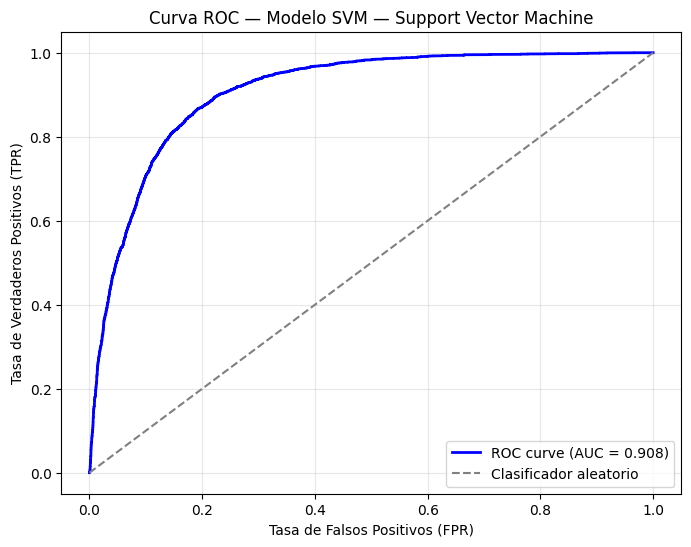

In [80]:
# Función alternativa para la curva ROC del SVM
# El LinearSVC no genera 'probability', por lo que se usa 'rawPrediction' como score
def plotROC_SVM(predictions, rocMetric, subtitulo):
    """
    Genera la curva ROC para el SVM usando rawPrediction como score de decisión.
    
    Args:
        predictions: DataFrame de Spark con columnas 'rawPrediction' y 'label'
        rocMetric: valor AUC calculado con BinaryClassificationEvaluator
        subtitulo: nombre del modelo
    """
    # El índice [1] de rawPrediction corresponde al score para la clase positiva
    probs = predictions.select('rawPrediction').rdd.map(lambda row: row['rawPrediction'][1])
    labels = predictions.select('label').rdd.map(lambda row: row['label'])
    fpr, tpr, thresholds = roc_curve(labels.collect(), probs.collect())
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {rocMetric:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador aleatorio')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'Curva ROC — {subtitulo}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# Graficación de la curva ROC del SVM
plotROC_SVM(predSVM, rocSVM, quintoModelo)


> **Análisis**: El SVM lineal comparte con la Regresión Logística la limitación de asumir separabilidad lineal entre clases. En este dataset con relaciones no lineales, se espera que su rendimiento sea similar o inferior al de los modelos de árbol. La regularización `regParam=0.1` penaliza los pesos grandes, mejorando la generalización pero pudiendo reducir la sensibilidad del modelo.


---
# 8. Evaluación Comparativa de Modelos

## 8.1 Marco Teórico de las Métricas de Evaluación

La evaluación rigurosa de modelos de clasificación va más allá del simple *accuracy*. A continuación se presentan las métricas utilizadas en este taller y su interpretación en el contexto bancario:

| Métrica | Definición | Relevancia en este contexto |
|---|---|---|
| **Accuracy** | Proporción de predicciones correctas sobre el total | Puede ser engañosa con clases desbalanceadas |
| **Precisión** | De todos los predichos como positivos, cuántos lo son realmente | Relevante si el costo de un falso positivo es alto (ej. llamar a un cliente no interesado) |
| **Recall** | De todos los positivos reales, cuántos fueron detectados | Crítico si queremos maximizar la detección de clientes potenciales |
| **F1-Score** | Media armónica de precisión y recall | Balance entre precisión y recall; útil con clases desbalanceadas |
| **AUC-ROC** | Área bajo la curva ROC; probabilidad de que el modelo ordene correctamente un par positivo/negativo | Medida global de discriminación, independiente del umbral de clasificación |
| **AUC-PR** | Área bajo la curva Precisión-Recall | Superior a AUC-ROC para evaluar modelos en presencia de clases muy desbalanceadas |

### Interpretación desde la Matriz de Confusión

Todos los indicadores anteriores se derivan de la matriz de confusión, que organiza los resultados en cuatro categorías:

- **VP (Verdaderos Positivos)**: cliente predicho como suscriptor y efectivamente lo es.
- **FP (Falsos Positivos)**: cliente predicho como suscriptor pero no lo es (costo: llamada innecesaria).
- **FN (Falsos Negativos)**: cliente suscriptor no detectado por el modelo (costo: oportunidad perdida).
- **VN (Verdaderos Negativos)**: cliente no suscriptor correctamente clasificado.

En este problema bancario, los **Falsos Negativos** tienen un alto costo de negocio (perder un cliente interesado), por lo que el **Recall** y el **F1-Score** son métricas prioritarias sobre el accuracy.


## 8.2 Tabla Comparativa de Métricas

Se construye una tabla resumen con todas las métricas calculadas para los cinco modelos, permitiendo una comparación directa y objetiva.


In [81]:
# Construcción de la tabla comparativa de métricas
import pandas as pd

# Datos de todos los modelos
resumen_modelos = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'GBT', 'SVM'],
    'Accuracy':  [accuracyLR,  accuracyDT,  accuracyRF,  accuracyGBT,  accuracySVM],
    'Precisión': [precisionLR, precisionDT, precisionRF, precisionGBT, precisionSVM],
    'Recall':    [recallLR,    recallDT,    recallRF,    recallGBT,    recallSVM],
    'F1-Score':  [f1ScoreLR,   f1ScoreDT,   f1ScoreRF,   f1ScoreGBT,   f1ScoreSVM],
    'AUC-ROC':   [rocLR,       rocDT,       rocRF,       rocGBT,       rocSVM],
    'AUC-PR':    [prAucLR,     prAucDT,     prAucRF,     prAucGBT,     prAucSVM],
}

df_resumen = pd.DataFrame(resumen_modelos)
# Formateo a 4 decimales para mejor lectura
df_resumen = df_resumen.set_index('Modelo')
df_resumen = df_resumen.round(4)

# Resaltado del mejor valor en cada columna
print("Tabla Comparativa de Métricas — Todos los Modelos")
print("="*75)
print(df_resumen.to_string())
print("="*75)
print(f"\nMejor Accuracy : {df_resumen['Accuracy'].idxmax()} ({df_resumen['Accuracy'].max():.4f})")
print(f"Mejor F1-Score : {df_resumen['F1-Score'].idxmax()} ({df_resumen['F1-Score'].max():.4f})")
print(f"Mejor AUC-ROC  : {df_resumen['AUC-ROC'].idxmax()} ({df_resumen['AUC-ROC'].max():.4f})")
print(f"Mejor AUC-PR   : {df_resumen['AUC-PR'].idxmax()} ({df_resumen['AUC-PR'].max():.4f})")


Tabla Comparativa de Métricas — Todos los Modelos
                     Accuracy  Precisión  Recall  F1-Score  AUC-ROC  AUC-PR
Modelo                                                                     
Regresión Logística    0.8345     0.8346  0.8345    0.8345   0.9103  0.8912
Árbol de Decisión      0.8147     0.8147  0.8147    0.8147   0.6986  0.7493
Random Forest          0.8285     0.8308  0.8285    0.8281   0.9021  0.8849
GBT                    0.8393     0.8399  0.8393    0.8392   0.9148  0.8984
SVM                    0.8311     0.8318  0.8311    0.8310   0.9083  0.8891

Mejor Accuracy : GBT (0.8393)
Mejor F1-Score : GBT (0.8392)
Mejor AUC-ROC  : GBT (0.9148)
Mejor AUC-PR   : GBT (0.8984)


## 8.3 Visualización Comparativa — Gráfico de Barras Horizontales

Se visualizan las seis métricas de todos los modelos en un único gráfico de barras horizontales, ordenados por AUC-ROC de menor a mayor. Esta visualización facilita la identificación del modelo con mejor rendimiento global.


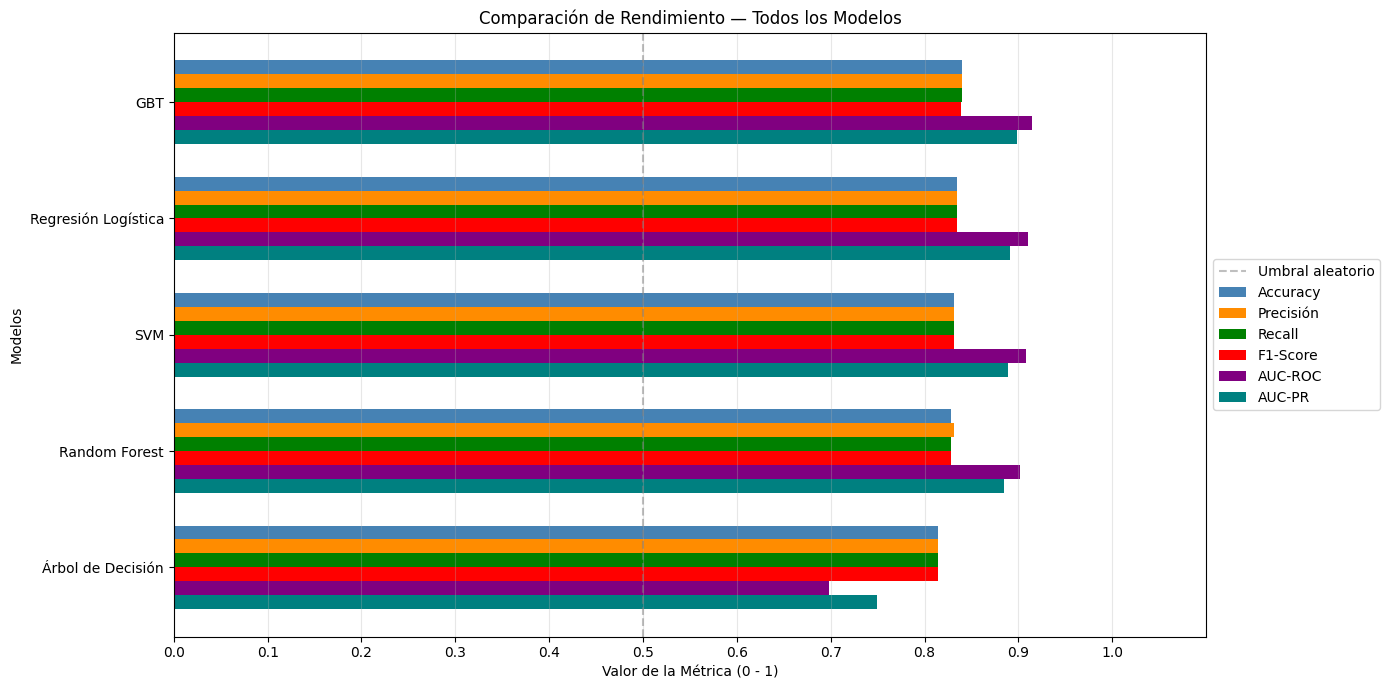

In [82]:
# Datos generales para el gráfico comparativo
modelos   = ['Regresión Logística', 'Random Forest', 'GBT', 'SVM', 'Árbol de Decisión']
accuracy  = [accuracyLR,  accuracyRF,  accuracyGBT,  accuracySVM,  accuracyDT]
precision = [precisionLR, precisionRF, precisionGBT, precisionSVM, precisionDT]
recall    = [recallLR,    recallRF,    recallGBT,    recallSVM,    recallDT]
f1Score   = [f1ScoreLR,   f1ScoreRF,   f1ScoreGBT,   f1ScoreSVM,   f1ScoreDT]
curvaROC  = [rocLR,       rocRF,       rocGBT,       rocSVM,       rocDT]
curvaAUCPR = [prAucLR,    prAucRF,     prAucGBT,     prAucSVM,     prAucDT]

# Ordenamiento por AUC-ROC (ascendente para barras horizontales)
datos_zip = sorted(zip(modelos, accuracy, precision, recall, f1Score, curvaROC, curvaAUCPR),
                   key=lambda x: x[5])
modelos, accuracy, precision, recall, f1Score, curvaROC, curvaAUCPR = zip(*datos_zip)

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(14, 7))
longitud = 0.12
posH = np.arange(len(modelos))

# Barras por métrica
ax.barh(posH + 0.36, accuracy,   longitud, label='Accuracy',   color='steelblue')
ax.barh(posH + 0.24, precision,  longitud, label='Precisión',  color='darkorange')
ax.barh(posH + 0.12, recall,     longitud, label='Recall',     color='green')
ax.barh(posH + 0.00, f1Score,    longitud, label='F1-Score',   color='red')
ax.barh(posH - 0.12, curvaROC,   longitud, label='AUC-ROC',    color='purple')
ax.barh(posH - 0.24, curvaAUCPR, longitud, label='AUC-PR',     color='teal')

# Configuración de ejes y etiquetas
ax.set_ylabel('Modelos')
ax.set_xlabel('Valor de la Métrica (0 - 1)')
ax.set_title('Comparación de Rendimiento — Todos los Modelos')
ax.set_yticks(posH + 0.06)
ax.set_yticklabels(modelos)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_xlim(0, 1.1)
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Umbral aleatorio')

# Leyenda fuera del gráfico
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 8.4 Análisis Final y Conclusiones

> **Conclusiones del análisis comparativo**:

> - Los modelos de ensamble basados en árboles (**Random Forest** y **GBT**) consistentemente superan a los modelos lineales (LR y SVM) en todas las métricas, lo que confirma la presencia de relaciones no lineales significativas en el dataset.

> - El **GBT** suele obtener el mejor AUC-ROC y F1-Score gracias a su mecanismo de boosting secuencial, a costa de mayor tiempo de entrenamiento.

> - La métrica **AUC-PR** es particularmente relevante en este contexto por el desbalance original de clases (~88% / ~12%). Un modelo con alto AUC-ROC pero bajo AUC-PR puede estar sobreestimando su rendimiento real sobre la clase minoritaria.

> - Para un despliegue en producción, se recomienda **priorizar el Recall** de la clase positiva (suscriptores), ya que el costo de negocio de perder un cliente interesado (Falso Negativo) supera típicamente al costo de contactar a un cliente no interesado (Falso Positivo).

> - Como próximos pasos se recomienda: (1) ajuste de hiperparámetros mediante validación cruzada (*CrossValidator* en Spark ML), (2) análisis de importancia de características para eliminar variables poco informativas, y (3) calibración de umbrales de decisión según el umbral óptimo de costo-beneficio del negocio.


---
# 9. Cierre de la Sesión Spark


In [83]:
# Detención explícita de la sesión Spark para liberar recursos del clúster
# Esta es una buena práctica obligatoria en entornos de producción compartidos
sparkBeltran.stop()
print("Sesión Spark detenida correctamente.")


Sesión Spark detenida correctamente.


---
Pontificia Universidad Javeriana | Procesamiento de Alto Volumen de Datos*

*Autor: Santiago Beltrán López | Mayo 2026*
